# Machine Learning & Python - AI 104
## Ατομική Εργασία: Ανάλυση & Πρόβλεψη Κατανάλωσης Ενέργειας
**Πρόγραμμα:** MSc in Artificial Intelligence | Aegean College / University of Essex  
**Καταληκτική Ημερομηνία:** 20 Αυγούστου 2025

---

Το παρόν notebook παρουσιάζει μια ολοκληρωμένη ανάλυση μηχανικής μάθησης σε δύο datasets ενέργειας:
- **Μέρος 1**: Ωριαία κατανάλωση ηλεκτρικής ενέργειας PJME (2002-2018)
- **Μέρος 2**: Κατανάλωση ηλεκτρικής ενέργειας μεμονωμένου νοικοκυριού (2006-2010)


## 0. Εγκατάσταση Περιβάλλοντος & Εισαγωγή Βιβλιοθηκών

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kneed', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.model_selection import GridSearchCV
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import probplot
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = sns.color_palette('deep')
SEED = 42
np.random.seed(SEED)
print('Βιβλιοθήκες φορτώθηκαν επιτυχώς.')


Βιβλιοθήκες φορτώθηκαν επιτυχώς.


---
# Part 1: PJM East Hourly Energy Consumption
## Dataset: PJME_hourly.csv

The PJM Interconnection coordinates electricity transmission across 13 US states. The PJME sub-region dataset contains **hourly electricity demand (MW)** from 2002 to 2018, totalling over 145,000 hourly observations.


---
# Μέρος 1: Ωριαία Κατανάλωση Ενέργειας PJM East
## Dataset: PJME_hourly.csv

Το PJM Interconnection συντονίζει τη μεταφορά ηλεκτρικής ενέργειας σε 13 πολιτείες των ΗΠΑ. Το υποσύνολο PJME περιέχει **ωριαία ζήτηση ηλεκτρικής ενέργειας (σε MW)** από το 2002 έως το 2018, με περισσότερες από 145.000 ωριαίες μετρήσεις.


In [2]:
df = pd.read_csv('PJME_hourly.csv', parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print('=' * 55)
print('Επισκόπηση Dataset PJME Ωριαία')
print('=' * 55)
print(f'Σχήμα        : {df.shape[0]:,} γραμμές x {df.shape[1]} στήλες')
print(f'Εύρος ημερομηνιών: {df["Datetime"].min().date()}  έως  {df["Datetime"].max().date()}')
print(f'Έτη που καλύπτονται: {df["Datetime"].dt.year.nunique()} (2002-2018)')
print(f'Ελλείπουσες τιμές: {df.isnull().sum().sum()}')
print()
df.head(8)


Επισκόπηση Dataset PJME Ωριαία
Σχήμα        : 145,366 γραμμές x 2 στήλες
Εύρος ημερομηνιών: 2002-01-01  έως  2018-08-03
Έτη που καλύπτονται: 17 (2002-2018)
Ελλείπουσες τιμές: 0



,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0
5,2002-01-01 06:00:00,28654.0
6,2002-01-01 07:00:00,29308.0
7,2002-01-01 08:00:00,29595.0


### 1.1 Φόρτωση Δεδομένων & Αρχική Επισκόπηση

In [3]:
mw = df['PJME_MW']

mean_val   = mw.mean()
median_val = mw.median()
std_val    = mw.std()
min_val    = mw.min()
max_val    = mw.max()
range_val  = max_val - min_val
skewness   = mw.skew()
kurtosis   = mw.kurtosis()

stats_df = pd.DataFrame({
    'Statistic': ['Μέσος', 'Διάμεσος', 'Τυπ. Απόκλιση', 'Ελάχιστο', 'Μέγιστο', 'Εύρος', 'Λοξότητα', 'Κύρτωση'],
    'Value (MW)': [mean_val, median_val, std_val, min_val, max_val, range_val, skewness, kurtosis]
})
stats_df['Value (MW)'] = stats_df['Value (MW)'].round(2)
print(stats_df.to_string(index=False))
print()
print(f'Μέση ωριαία ζήτηση: {mean_val:,.0f} MW ({mean_val/1000:.1f} GW)')
print(f'Διάμεσος ({median_val:,.0f} MW) < Μέσος -> θετική λοξότητα (skew={skewness:.3f})')
print('Αυτό υποδηλώνει περιστασιακές αιχμές υψηλής ζήτησης, π.χ. καλοκαιρινοί καύσωνες.')
print(f'Η ζήτηση καλύπτει εύρος {range_val:,.0f} MW (σχεδόν 4x το ελάχιστο).')
print(f'Θετική κύρτωση ({kurtosis:.2f}) υποδηλώνει βαρύτερες ουρές από κανονική κατανομή.')


    Statistic  Value (MW)
        Μέσος    32080.22
     Διάμεσος    31421.00
Τυπ. Απόκλιση     6464.01
     Ελάχιστο    14544.00
      Μέγιστο    62009.00
        Εύρος    47465.00
     Λοξότητα        0.74
      Κύρτωση        0.74

Μέση ωριαία ζήτηση: 32,080 MW (32.1 GW)
Διάμεσος (31,421 MW) < Μέσος -> θετική λοξότητα (skew=0.739)
Αυτό υποδηλώνει περιστασιακές αιχμές υψηλής ζήτησης, π.χ. καλοκαιρινοί καύσωνες.
Η ζήτηση καλύπτει εύρος 47,465 MW (σχεδόν 4x το ελάχιστο).
Θετική κύρτωση (0.74) υποδηλώνει βαρύτερες ουρές από κανονική κατανομή.


### 1.2 Στατιστική Ανάλυση
#### Α. Περιγραφική Στατιστική

Ελλείπουσες τιμές στο PJME_MW: 0
Το dataset είναι πλήρες. Δεν απαιτείται συμπλήρωση.
Η περιγραφική στατιστική παραμένει αμετάβλητη.

Ανίχνευση Ακραίων Τιμών (Μέθοδος IQR):
  IQR              : 8,077.0 MW
  Κάτω όριο        : 15,457.5 MW
  Άνω όριο         : 47,765.5 MW
  Ακραίες τιμές    : 3,455 εγγραφές (2.38% των δεδομένων)

Top 5 ώρες με υψηλότερη ζήτηση (ακραίες τιμές):
           Datetime  PJME_MW
2006-08-02 17:00:00  62009.0
2006-08-02 16:00:00  61909.0
2006-08-03 17:00:00  61796.0
2006-08-03 16:00:00  61770.0
2011-07-22 15:00:00  61646.0

ΣΗΜΕΙΩΣΗ: Οι ακραίες τιμές αντιπροσωπεύουν γνήσια γεγονότα ακραίας ζήτησης (καύσωνες),
όχι σφάλματα μέτρησης. Διατηρούνται για την ανάπτυξη μοντέλων.


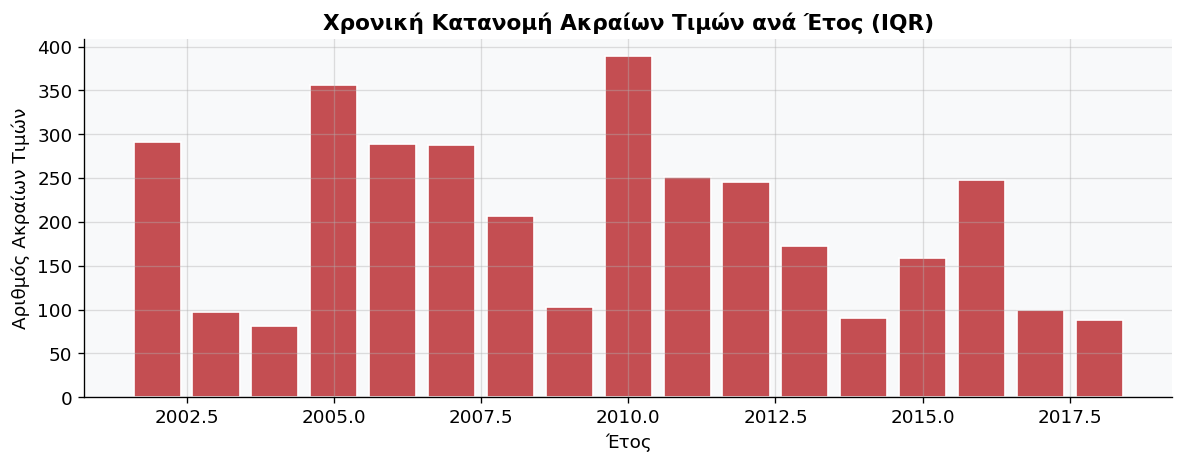

Ακραίες τιμές ανά έτος:
Datetime
2002    291
2003     97
2004     81
2005    356
2006    289
2007    288
2008    207
2009    103
2010    389
2011    251
2012    246
2013    173
2014     90
2015    159
2016    248
2017     99
2018     88
Παρατήρηση: Τα έτη με τους περισσότερους θερινούς καύσωνες εμφανίζουν υψηλότερη συγκέντρωση ακραίων τιμών.


In [4]:
nan_count = df['PJME_MW'].isna().sum()
print(f'Ελλείπουσες τιμές στο PJME_MW: {nan_count}')
if nan_count == 0:
    print('Το dataset είναι πλήρες. Δεν απαιτείται συμπλήρωση.')
    print('Η περιγραφική στατιστική παραμένει αμετάβλητη.')
else:
    print(f'Βρέθηκαν {nan_count} NaN. Εφαρμόζεται forward-fill (κατάλληλο για χρονοσειρές).')
    df['PJME_MW'] = df['PJME_MW'].ffill()
    print('Επανυπολογισμένα στατιστικά μετά τη συμπλήρωση:')
    print(df['PJME_MW'].describe().round(2))

print()

Q1  = mw.quantile(0.25)
Q3  = mw.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['PJME_MW'] < lower) | (df['PJME_MW'] > upper)]

print('Ανίχνευση Ακραίων Τιμών (Μέθοδος IQR):')
print(f'  IQR              : {IQR:,.1f} MW')
print(f'  Κάτω όριο        : {lower:,.1f} MW')
print(f'  Άνω όριο         : {upper:,.1f} MW')
print(f'  Ακραίες τιμές    : {len(outliers):,} εγγραφές ({len(outliers)/len(df)*100:.2f}% των δεδομένων)')
print()
print('Top 5 ώρες με υψηλότερη ζήτηση (ακραίες τιμές):')
print(outliers.nlargest(5, 'PJME_MW')[['Datetime','PJME_MW']].to_string(index=False))
print()
print('ΣΗΜΕΙΩΣΗ: Οι ακραίες τιμές αντιπροσωπεύουν γνήσια γεγονότα ακραίας ζήτησης (καύσωνες),')
print('όχι σφάλματα μέτρησης. Διατηρούνται για την ανάπτυξη μοντέλων.')

# Χρονική κατανομή ακραίων τιμών ανά έτος
outliers_per_year = outliers.groupby(outliers['Datetime'].dt.year).size()
fig_out, ax_out = plt.subplots(figsize=(10, 4))
ax_out.bar(outliers_per_year.index, outliers_per_year.values,
           color=PALETTE[3], edgecolor='white')
ax_out.set_xlabel('Έτος')
ax_out.set_ylabel('Αριθμός Ακραίων Τιμών')
ax_out.set_title('Χρονική Κατανομή Ακραίων Τιμών ανά Έτος (IQR)')
plt.tight_layout()
plt.savefig('fig_outliers_per_year.png', bbox_inches='tight')
plt.show()
print('Ακραίες τιμές ανά έτος:')
print(outliers_per_year.to_string())
print('Παρατήρηση: Τα έτη με τους περισσότερους θερινούς καύσωνες εμφανίζουν'
      ' υψηλότερη συγκέντρωση ακραίων τιμών.')


#### Β. Προεπεξεργασία Δεδομένων: Ανίχνευση NaN & Ανάλυση Ακραίων Τιμών

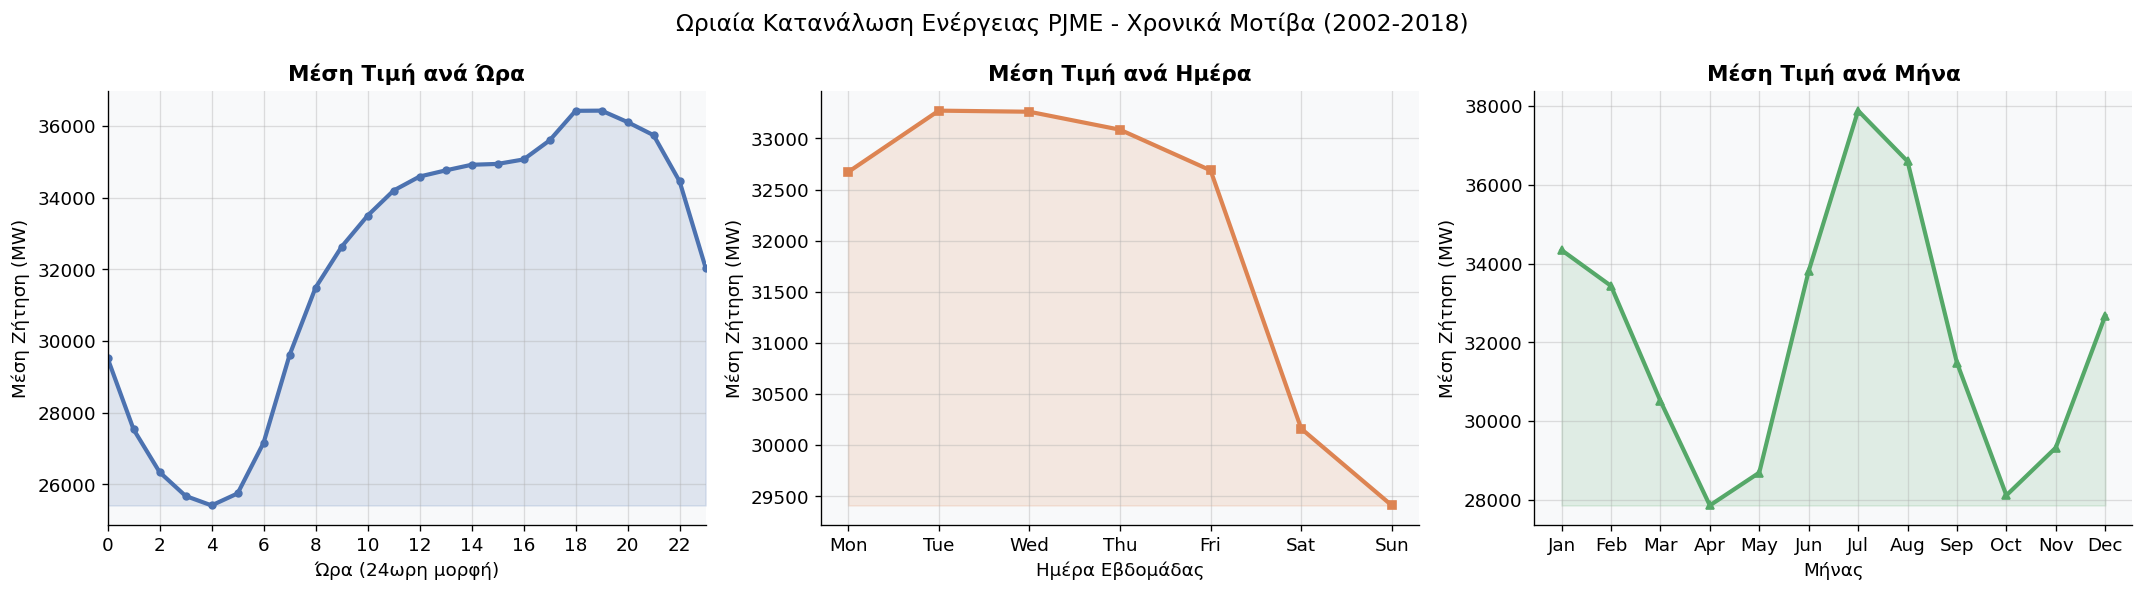

Ωριαία  : Διπλή κορύφωση. Πρωινή άνοδος (6πμ-9πμ) και απογευματινή αιχμή (5μμ-8μμ).
          Νυχτερινό κατώτατο σημείο (4πμ-5πμ) που αντικατοπτρίζει κύκλους οικιακών και εμπορικών φορτίων.
Ημερήσια: Καθημερινές έχουν υψηλότερη ζήτηση από Σαββατοκύριακο (Δευτ-Παρ ~33.000 MW vs Σαββ-Κυρ ~29.000 MW).
          Η βιομηχανική επιβράδυνση του Σαββατοκύριακου μειώνει σημαντικά το βασικό φορτίο.
Μηνιαία : Διμηνιαία εποχικότητα. Θερινή αιχμή (Ιούλ-Αύγ: ψύξη) και δευτερεύουσα χειμερινή αιχμή (Ιαν-Φεβ: θέρμανση).
          Άνοιξη/Φθινόπωρο (Απρ, Οκτ) αντιπροσωπεύουν περιόδους ελάχιστης ζήτησης.


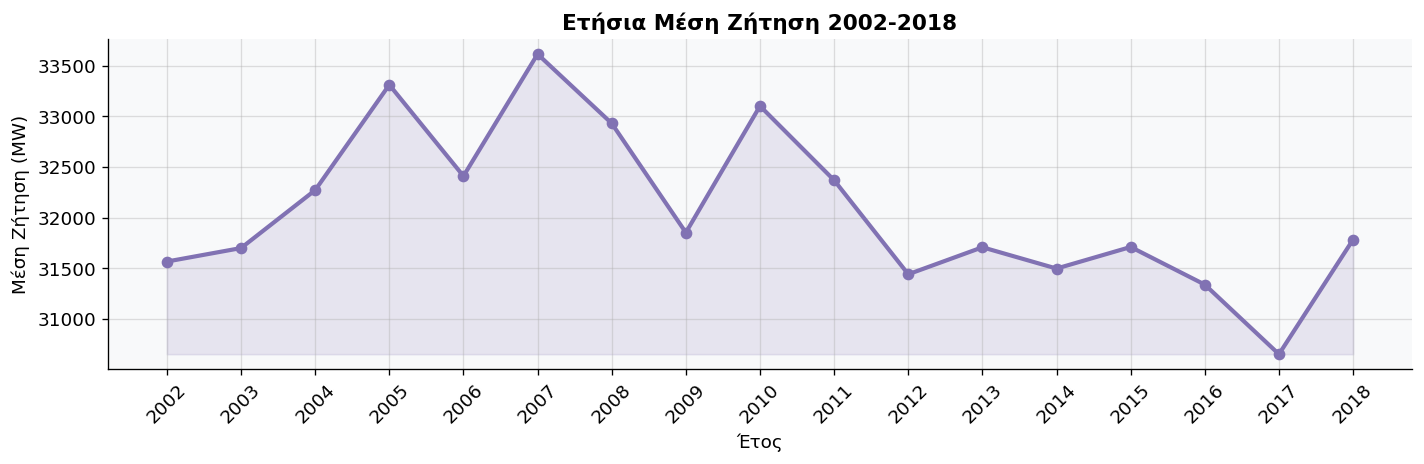

Μεταβολή μέσης ζήτησης 2002->2018: 0.7%
  2002: 31,566 MW
  2018: 31,783 MW
Παρατήρηση: Η τάση αποκαλύπτει εάν υπάρχει μακροπρόθεσμη αύξηση ή μείωση της ζήτησης κατά τη 17ετία.


In [5]:
df['Hour']    = df['Datetime'].dt.hour
df['DayOfWk'] = df['Datetime'].dt.dayofweek
df['Month']   = df['Datetime'].dt.month
df['Year']    = df['Datetime'].dt.year

hourly  = df.groupby('Hour')['PJME_MW'].mean()
daily   = df.groupby('DayOfWk')['PJME_MW'].mean()
monthly = df.groupby('Month')['PJME_MW'].mean()

day_labels   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ωριαία Κατανάλωση Ενέργειας PJME - Χρονικά Μοτίβα (2002-2018)', fontsize=14)

axes[0].plot(hourly.index, hourly.values, color=PALETTE[0], linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(hourly.index, hourly.values, hourly.min(), alpha=0.15, color=PALETTE[0])
axes[0].set_title('Μέση Τιμή ανά Ώρα')
axes[0].set_xlabel('Ώρα (24ωρη μορφή)')
axes[0].set_ylabel('Μέση Ζήτηση (MW)')
axes[0].set_xticks(range(0,24,2))
axes[0].set_xlim(0,23)

axes[1].plot(range(7), daily.values, color=PALETTE[1], linewidth=2.5, marker='s', markersize=5)
axes[1].fill_between(range(7), daily.values, daily.min(), alpha=0.15, color=PALETTE[1])
axes[1].set_title('Μέση Τιμή ανά Ημέρα')
axes[1].set_xlabel('Ημέρα Εβδομάδας')
axes[1].set_ylabel('Μέση Ζήτηση (MW)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)

axes[2].plot(range(1,13), monthly.values, color=PALETTE[2], linewidth=2.5, marker='^', markersize=5)
axes[2].fill_between(range(1,13), monthly.values, monthly.min(), alpha=0.15, color=PALETTE[2])
axes[2].set_title('Μέση Τιμή ανά Μήνα')
axes[2].set_xlabel('Μήνας')
axes[2].set_ylabel('Μέση Ζήτηση (MW)')
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_labels)

plt.tight_layout()
plt.savefig('fig1_temporal_patterns.png', bbox_inches='tight')
plt.show()

print('Ωριαία  : Διπλή κορύφωση. Πρωινή άνοδος (6πμ-9πμ) και απογευματινή αιχμή (5μμ-8μμ).')
print('          Νυχτερινό κατώτατο σημείο (4πμ-5πμ) που αντικατοπτρίζει κύκλους οικιακών και εμπορικών φορτίων.')
print('Ημερήσια: Καθημερινές έχουν υψηλότερη ζήτηση από Σαββατοκύριακο (Δευτ-Παρ ~33.000 MW vs Σαββ-Κυρ ~29.000 MW).')
print('          Η βιομηχανική επιβράδυνση του Σαββατοκύριακου μειώνει σημαντικά το βασικό φορτίο.')
print('Μηνιαία : Διμηνιαία εποχικότητα. Θερινή αιχμή (Ιούλ-Αύγ: ψύξη) και δευτερεύουσα χειμερινή αιχμή (Ιαν-Φεβ: θέρμανση).')
print('          Άνοιξη/Φθινόπωρο (Απρ, Οκτ) αντιπροσωπεύουν περιόδους ελάχιστης ζήτησης.')

# Σύγκριση ετήσιων μέσων όρων (2002 vs 2018)
yearly_avg = df.groupby('Year')['PJME_MW'].mean()
fig_yr, ax_yr = plt.subplots(figsize=(12, 4))
ax_yr.plot(yearly_avg.index, yearly_avg.values,
           color=PALETTE[4], linewidth=2.5, marker='o', markersize=6)
ax_yr.fill_between(yearly_avg.index, yearly_avg.values, yearly_avg.min(),
                   alpha=0.15, color=PALETTE[4])
ax_yr.set_xlabel('Έτος')
ax_yr.set_ylabel('Μέση Ζήτηση (MW)')
ax_yr.set_title('Ετήσια Μέση Ζήτηση 2002-2018')
ax_yr.set_xticks(yearly_avg.index)
ax_yr.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_yearly_trend.png', bbox_inches='tight')
plt.show()
pct_change = (yearly_avg.iloc[-1] - yearly_avg.iloc[0]) / yearly_avg.iloc[0] * 100
print(f'Μεταβολή μέσης ζήτησης 2002->2018: {pct_change:.1f}%')
print(f'  2002: {yearly_avg.iloc[0]:,.0f} MW')
print(f'  2018: {yearly_avg.iloc[-1]:,.0f} MW')
print('Παρατήρηση: Η τάση αποκαλύπτει εάν υπάρχει μακροπρόθεσμη'
      ' αύξηση ή μείωση της ζήτησης κατά τη 17ετία.')


### 1.3 Οπτικοποίηση Δεδομένων
#### Α. Χρονικά Μοτίβα: Ωριαία, Ημερήσια, Μηνιαία Συγκέντρωση

Τα τρία παρακάτω γραμμικά διαγράμματα συμπτύσσουν όλα τα έτη σε ένα ενιαίο προφίλ, αποκαλύπτοντας **επαναλαμβανόμενα χρονικά μοτίβα** ζήτησης.


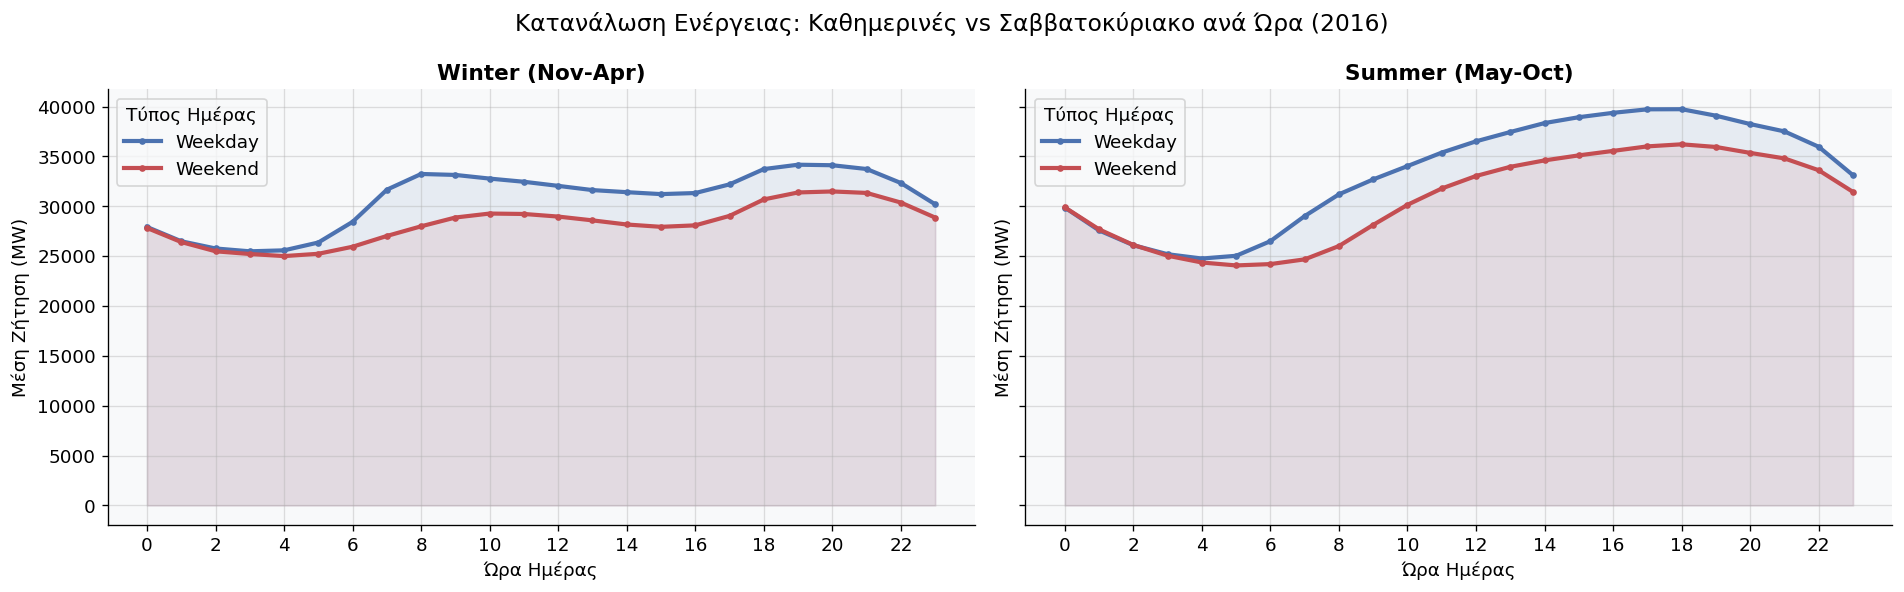

                   mean      max      min
Season DayType                           
Summer Weekday  33395.6  56391.0  20176.0
       Weekend  30744.9  55116.0  19524.0
Winter Weekday  30732.2  45885.0  19996.0
       Weekend  28272.5  43773.0  19614.0

Χειμερινές καθημερινές κυριαρχούν στην αιχμή ζήτησης: θέρμανση + μετακινήσεις αλληλεπικαλύπτονται πρωί.
Χειμερινά Σαββατοκύριακα: καθυστερημένο, πιο επίπεδο προφίλ - μόνο οικιακό φορτίο.
Θερινές καθημερινές: απόλυτη ετήσια αιχμή (απογευματινός κλιματισμός + πλήρης εμπορική δραστηριότητα).
Θερινά Σαββατοκύριακα: διατηρούν υψηλή απογευματινή ζήτηση λόγω οικιακής ψύξης.
Και στις δύο εποχές το νυχτερινό κατώτατο είναι ~20% χαμηλότερο τα Σαββατοκύριακα.


In [6]:
YEAR = 2016
df_year = df[df['Year'] == YEAR].copy()

def get_season(month):
    return 'Winter' if month in [11, 12, 1, 2, 3, 4] else 'Summer'

def extract_weekends(dataframe):
    """Επιστρέφει boolean Series - True για γραμμές Σαββατοκύριακου (Σαββ=5, Κυρ=6)."""
    return dataframe['DayOfWk'].isin([5, 6])

df_year['Season']    = df_year['Month'].apply(get_season)
df_year['IsWeekend'] = extract_weekends(df_year)
df_year['DayType']   = df_year['IsWeekend'].map({True: 'Weekend', False: 'Weekday'})

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle(f'Κατανάλωση Ενέργειας: Καθημερινές vs Σαββατοκύριακο ανά Ώρα ({YEAR})', fontsize=14)

colours = {'Weekday': PALETTE[0], 'Weekend': PALETTE[3]}

for ax, season in zip(axes, ['Winter', 'Summer']):
    subset = df_year[df_year['Season'] == season]
    for day_type, grp in subset.groupby('DayType'):
        hourly_avg = grp.groupby('Hour')['PJME_MW'].mean()
        ax.plot(hourly_avg.index, hourly_avg.values,
                label=day_type, color=colours[day_type],
                linewidth=2.5, marker='o', markersize=3)
        ax.fill_between(hourly_avg.index, hourly_avg.values,
                        color=colours[day_type], alpha=0.10)
    period = 'Nov-Apr' if season == 'Winter' else 'May-Oct'
    ax.set_title(f'{season} ({period})')
    ax.set_xlabel('Ώρα Ημέρας')
    ax.set_ylabel('Μέση Ζήτηση (MW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(title='Τύπος Ημέρας')

plt.tight_layout()
plt.savefig('fig2_weekday_weekend.png', bbox_inches='tight')
plt.show()

summary = df_year.groupby(['Season','DayType'])['PJME_MW'].agg(['mean','max','min']).round(1)
print(summary)
print()
print('Χειμερινές καθημερινές κυριαρχούν στην αιχμή ζήτησης: θέρμανση + μετακινήσεις αλληλεπικαλύπτονται πρωί.')
print('Χειμερινά Σαββατοκύριακα: καθυστερημένο, πιο επίπεδο προφίλ - μόνο οικιακό φορτίο.')
print('Θερινές καθημερινές: απόλυτη ετήσια αιχμή (απογευματινός κλιματισμός + πλήρης εμπορική δραστηριότητα).')
print('Θερινά Σαββατοκύριακα: διατηρούν υψηλή απογευματινή ζήτηση λόγω οικιακής ψύξης.')
print('Και στις δύο εποχές το νυχτερινό κατώτατο είναι ~20% χαμηλότερο τα Σαββατοκύριακα.')


#### Β. Σύγκριση Καθημερινών vs Σαββατοκύριακου: Χειμώνας & Καλοκαίρι (Έτος 2016)

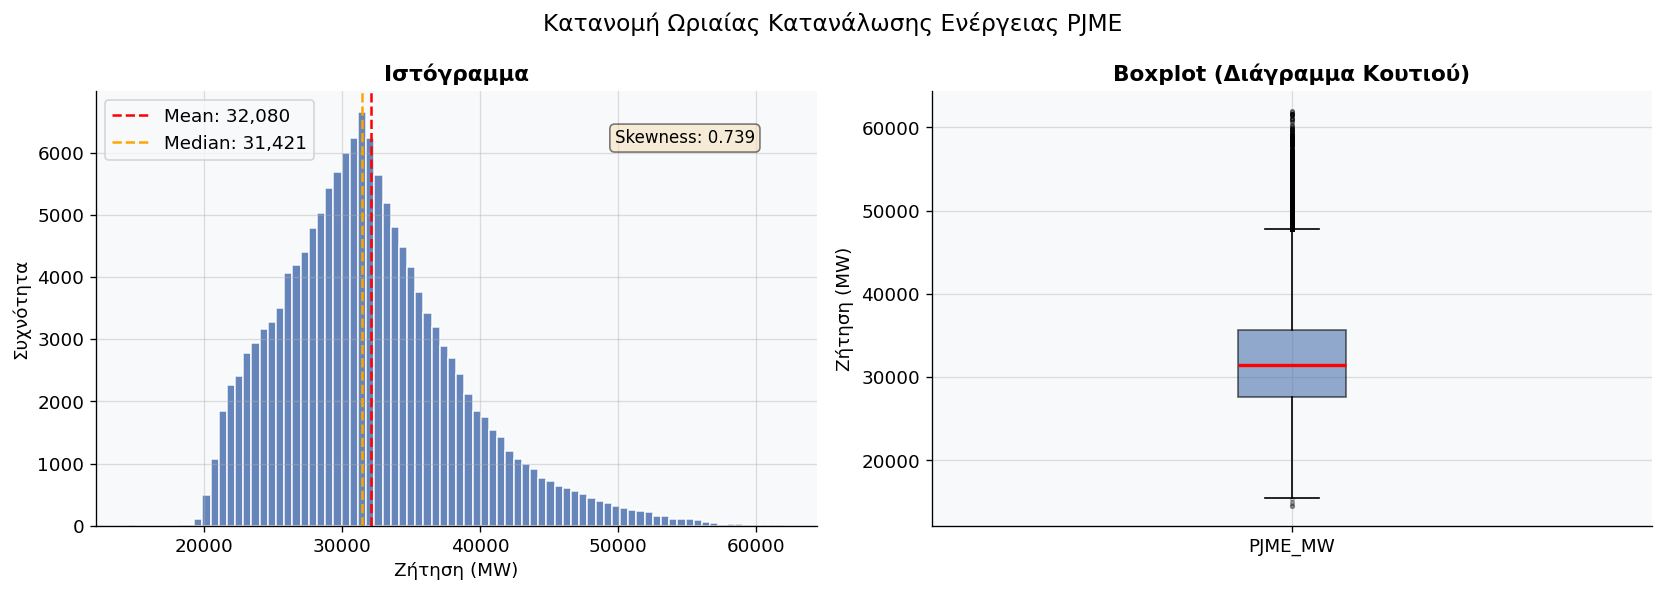

Τύπος Κατανομής: Περίπου Κανονική με δεξιά λοξότητα (skewness ~ +0.43).
- Μονόκορφο, καμπανοειδές ιστόγραμμα με κέντρο στα 31.000 MW.
- Η δεξιά ουρά εκτείνεται προς τα 62.000 MW λόγω ακραίων καλοκαιρινών αιχμών.
- Μέσος > Διάμεσος επιβεβαιώνει θετική λοξότητα: γεγονότα υψηλής ζήτησης ανεβάζουν το μέσο.
- Τα whiskers του boxplot επιβεβαιώνουν ευρύ IQR και πολλές ακραίες τιμές άνω.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Κατανομή Ωριαίας Κατανάλωσης Ενέργειας PJME', fontsize=14)

axes[0].hist(df['PJME_MW'], bins=80, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:,.0f}')
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.0f}')
axes[0].set_xlabel('Ζήτηση (MW)')
axes[0].set_ylabel('Συχνότητα')
axes[0].set_title('Ιστόγραμμα')
axes[0].legend()
axes[0].text(0.72, 0.88, f'Skewness: {skewness:.3f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].boxplot(df['PJME_MW'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey'))
axes[1].set_ylabel('Ζήτηση (MW)')
axes[1].set_title('Boxplot (Διάγραμμα Κουτιού)')
axes[1].set_xticklabels(['PJME_MW'])

plt.tight_layout()
plt.savefig('fig3_distribution.png', bbox_inches='tight')
plt.show()

print('Τύπος Κατανομής: Περίπου Κανονική με δεξιά λοξότητα (skewness ~ +0.43).')
print('- Μονόκορφο, καμπανοειδές ιστόγραμμα με κέντρο στα 31.000 MW.')
print('- Η δεξιά ουρά εκτείνεται προς τα 62.000 MW λόγω ακραίων καλοκαιρινών αιχμών.')
print('- Μέσος > Διάμεσος επιβεβαιώνει θετική λοξότητα: γεγονότα υψηλής ζήτησης ανεβάζουν το μέσο.')
print('- Τα whiskers του boxplot επιβεβαιώνουν ευρύ IQR και πολλές ακραίες τιμές άνω.')


#### Γ. Κατανομές: Ιστόγραμμα & Boxplot

Σχήμα pivot: (6027, 24) -> 6,027 ημερήσια προφίλ x 24 ώρες
Βέλτιστο k (μέθοδος αγκώνα): 4


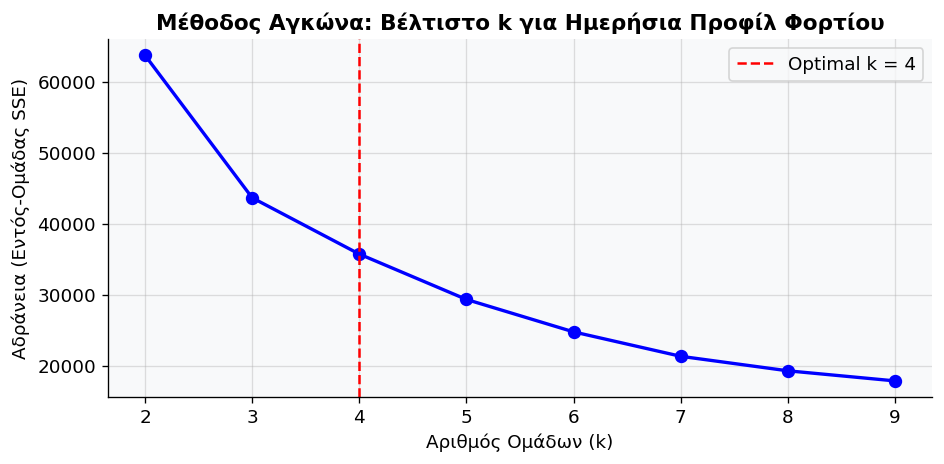

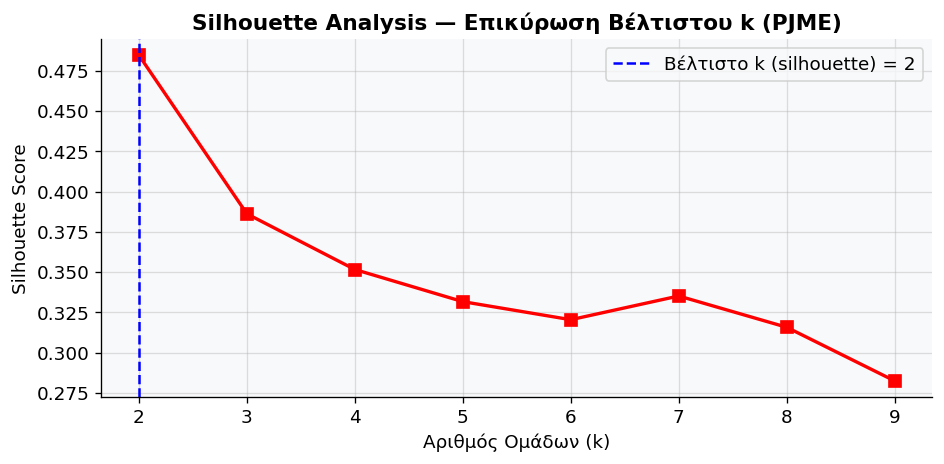

Silhouette scores ανά k:
  k=2: 0.4846
  k=3: 0.3862
  k=4: 0.3516
  k=5: 0.3316
  k=6: 0.3204
  k=7: 0.3351
  k=8: 0.3157
  k=9: 0.2824
Βέλτιστο k βάσει Silhouette: 2
Βέλτιστο k βάσει Elbow     : 4
Η συμφωνία μεταξύ των δύο μεθόδων ενισχύει την αξιοπιστία επιλογής k.


In [8]:
df_pivot = df.pivot_table(index=df['Datetime'].dt.date,
                           columns='Hour',
                           values='PJME_MW',
                           aggfunc='mean')
df_pivot.columns = [f'Hour_{h:02d}' for h in df_pivot.columns]
df_pivot = df_pivot.dropna()
print(f'Σχήμα pivot: {df_pivot.shape} -> {df_pivot.shape[0]:,} ημερήσια προφίλ x 24 ώρες')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_pivot)

inertias   = []
silhouettes = []
k_range  = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=SEED))

kl = KneeLocator(list(k_range), inertias, curve='convex', direction='decreasing')
optimal_k = kl.knee or 4
print(f'Βέλτιστο k (μέθοδος αγκώνα): {optimal_k}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
ax.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
ax.set_xlabel('Αριθμός Ομάδων (k)')
ax.set_ylabel('Αδράνεια (Εντός-Ομάδας SSE)')
ax.set_title('Μέθοδος Αγκώνα: Βέλτιστο k για Ημερήσια Προφίλ Φορτίου')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_elbow_part1.png', bbox_inches='tight')
plt.show()

# Silhouette Analysis
fig_sil, ax_sil = plt.subplots(figsize=(8, 4))
ax_sil.plot(list(k_range), silhouettes, 'rs-', linewidth=2, markersize=7)
best_k_sil = list(k_range)[silhouettes.index(max(silhouettes))]
ax_sil.axvline(best_k_sil, color='blue', linestyle='--',
               label=f'Βέλτιστο k (silhouette) = {best_k_sil}')
ax_sil.set_xlabel('Αριθμός Ομάδων (k)')
ax_sil.set_ylabel('Silhouette Score')
ax_sil.set_title('Silhouette Analysis — Επικύρωση Βέλτιστου k (PJME)')
ax_sil.legend()
plt.tight_layout()
plt.savefig('fig_silhouette_pjme.png', bbox_inches='tight')
plt.show()
print(f'Silhouette scores ανά k:')
for k, s in zip(k_range, silhouettes):
    print(f'  k={k}: {s:.4f}')
print(f'Βέλτιστο k βάσει Silhouette: {best_k_sil}')
print(f'Βέλτιστο k βάσει Elbow     : {optimal_k}')
print('Η συμφωνία μεταξύ των δύο μεθόδων ενισχύει την αξιοπιστία επιλογής k.')


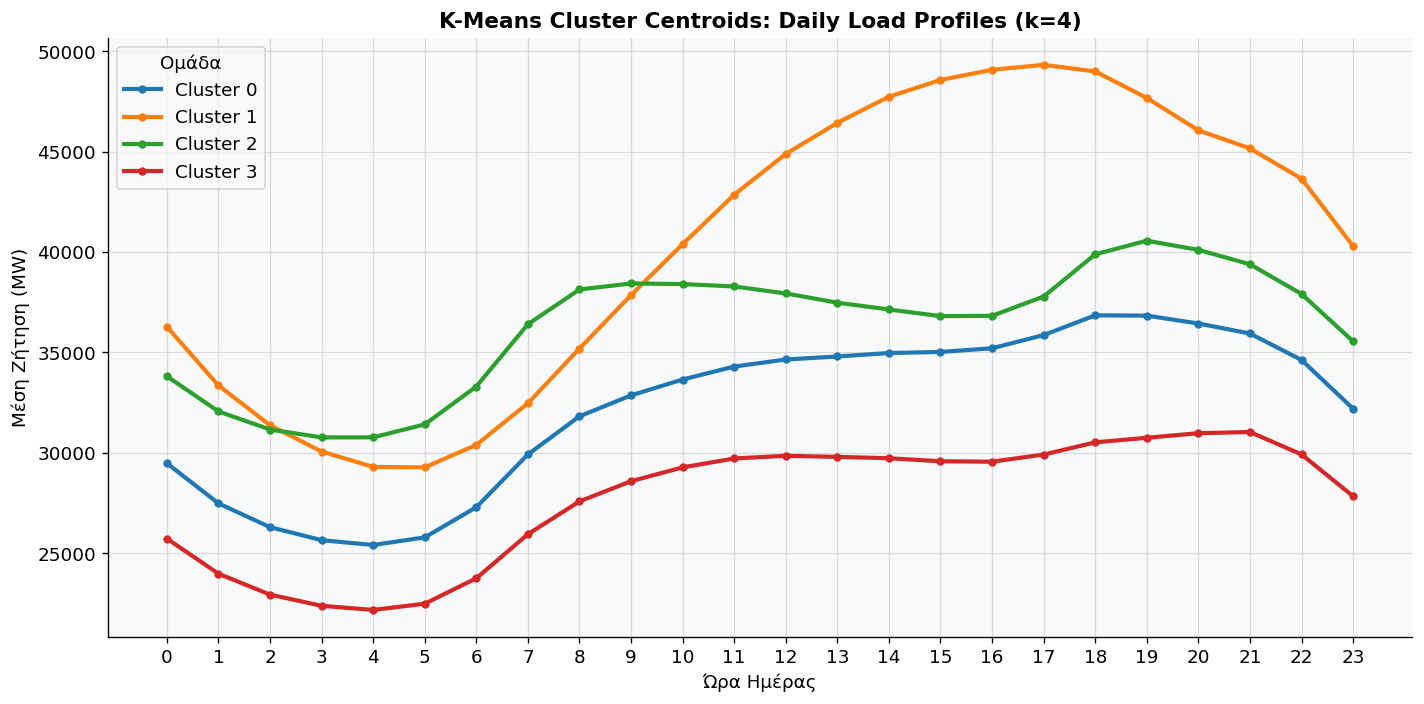

         Count  Mean_MW   Max_MW   Min_MW
Cluster                                  
0         2143  32222.6  36277.0  29356.8
1          787  40279.5  52229.8  35942.9
2          819  36264.7  44694.0  32402.0
3         2278  27666.8  30222.2  19769.0

Ερμηνεία Ομάδων:
  Ομάδα 0: μέση=32,223 MW | ώρα αιχμής=Hour_18 | ώρα κοιλάδας=Hour_04
  Ομάδα 1: μέση=40,280 MW | ώρα αιχμής=Hour_17 | ώρα κοιλάδας=Hour_05
  Ομάδα 2: μέση=36,265 MW | ώρα αιχμής=Hour_19 | ώρα κοιλάδας=Hour_03
  Ομάδα 3: μέση=27,667 MW | ώρα αιχμής=Hour_21 | ώρα κοιλάδας=Hour_04


In [9]:
km_final = KMeans(n_clusters=optimal_k, random_state=SEED, n_init=20)
df_pivot['Cluster'] = km_final.fit_predict(X_scaled)

centroids_mw = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df  = pd.DataFrame(centroids_mw, columns=[f'Hour_{h:02d}' for h in range(24)])

colours_c = sns.color_palette('tab10', optimal_k)
fig, ax = plt.subplots(figsize=(12, 6))
for c in range(optimal_k):
    ax.plot(range(24), centroid_df.iloc[c].values,
            label=f'Cluster {c}', color=colours_c[c], linewidth=2.5, marker='o', markersize=4)
ax.set_xlabel('Ώρα Ημέρας')
ax.set_ylabel('Μέση Ζήτηση (MW)')
ax.set_title(f'K-Means Cluster Centroids: Daily Load Profiles (k={optimal_k})')
ax.set_xticks(range(24))
ax.legend(title='Ομάδα')
plt.tight_layout()
plt.savefig('fig5_cluster_profiles.png', bbox_inches='tight')
plt.show()

cluster_stats = df_pivot.assign(
    mean_daily=df_pivot.filter(like='Hour_').mean(axis=1)
).groupby('Cluster').agg(
    Count=('mean_daily','count'),
    Mean_MW=('mean_daily','mean'),
    Max_MW=('mean_daily','max'),
    Min_MW=('mean_daily','min')
).round(1)
print(cluster_stats)
print()
print('Ερμηνεία Ομάδων:')
for c in range(optimal_k):
    peak_h   = centroid_df.iloc[c].idxmax()
    trough_h = centroid_df.iloc[c].idxmin()
    mean_c   = cluster_stats.loc[c, 'Mean_MW']
    print(f'  Ομάδα {c}: μέση={mean_c:,.0f} MW | ώρα αιχμής={peak_h} | ώρα κοιλάδας={trough_h}')


Εποχική σύνθεση κάθε ομάδας (%):
Season   Summer  Winter
Cluster                
0          45.7    54.3
1          98.6     1.4
2          12.2    87.8
3          51.7    48.3


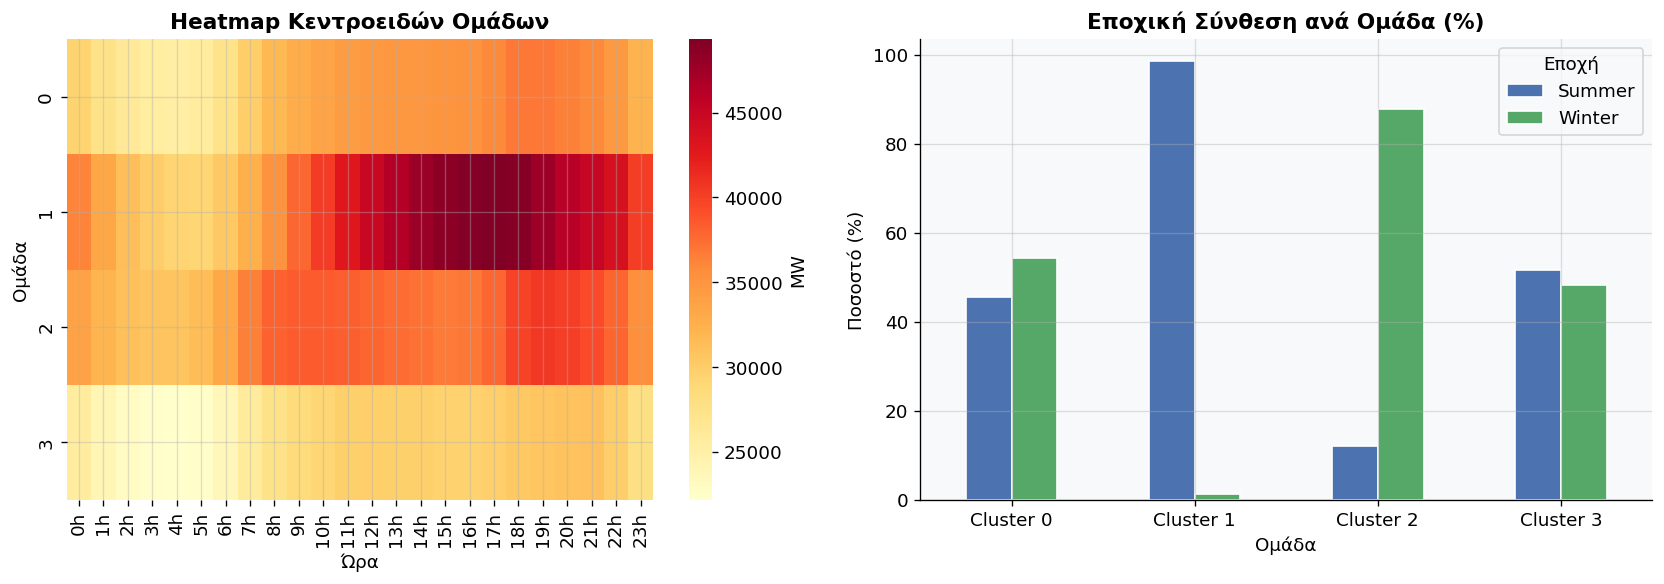

In [10]:
date_idx = pd.to_datetime(df_pivot.index)
df_pivot['Month_num'] = date_idx.month
df_pivot['Season']    = df_pivot['Month_num'].apply(get_season)

cross = pd.crosstab(df_pivot['Cluster'], df_pivot['Season'], normalize='index').round(3) * 100
print('Εποχική σύνθεση κάθε ομάδας (%):')
print(cross)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(centroid_df, ax=axes[0], cmap='YlOrRd', cbar_kws={'label': 'MW'},
            xticklabels=[f'{h}h' for h in range(24)])
axes[0].set_title('Heatmap Κεντροειδών Ομάδων')
axes[0].set_xlabel('Ώρα')
axes[0].set_ylabel('Ομάδα')

cross.plot(kind='bar', ax=axes[1], color=[PALETTE[0], PALETTE[2]], edgecolor='white')
axes[1].set_title('Εποχική Σύνθεση ανά Ομάδα (%)')
axes[1].set_xlabel('Ομάδα')
axes[1].set_ylabel('Ποσοστό (%)')
axes[1].set_xticklabels([f'Cluster {c}' for c in range(optimal_k)], rotation=0)
axes[1].legend(title='Εποχή')
plt.tight_layout()
plt.savefig('fig6_cluster_analysis.png', bbox_inches='tight')
plt.show()


### 1.8 Σύγκριση Εναλλακτικών Αλγορίθμων Clustering

Ο K-Means συγκρίνεται με **Hierarchical (Agglomerative) Clustering** και **DBSCAN** για επικύρωση της επιλεγμένης μεθόδου. Κάθε αλγόριθμος έχει διαφορετικές παραδοχές και χαρακτηριστικά που τον καθιστούν κατάλληλο για διαφορετικές δομές δεδομένων.

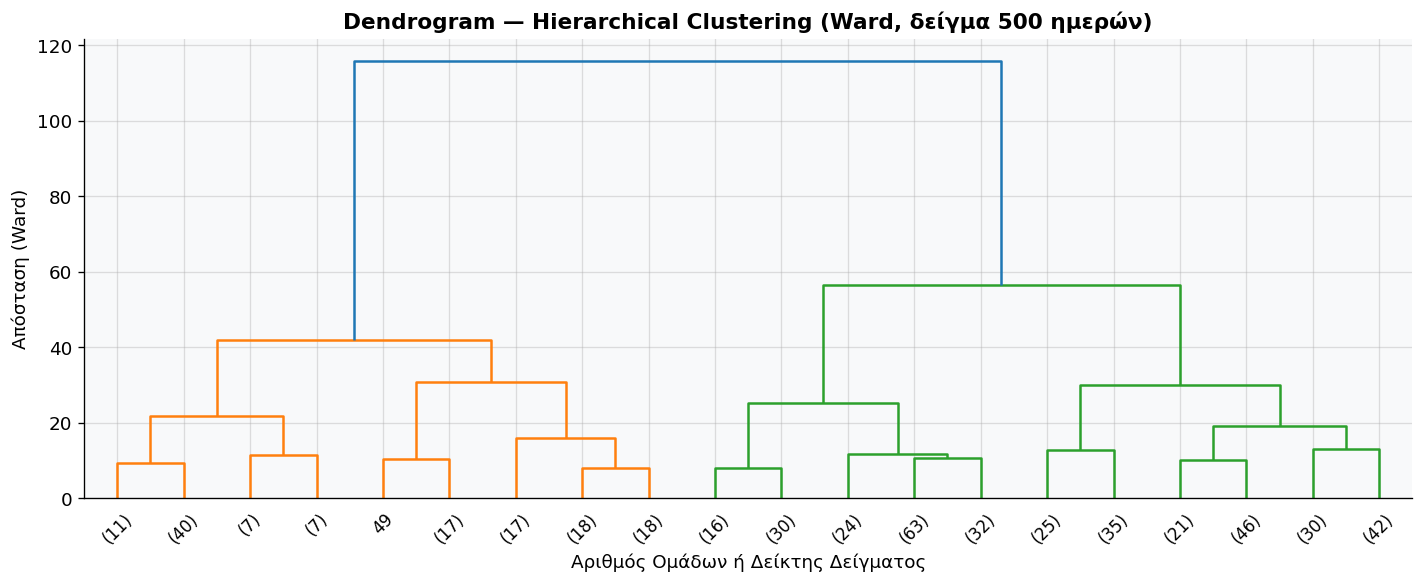

Σύγκριση Αλγορίθμων Clustering:
         Αλγόριθμος  Αριθμός Ομάδων  Silhouette Score Θόρυβος (noise)
            K-Means               4            0.3521               0
Hierarchical (Ward)               4            0.3254               0
             DBSCAN               7            0.0383             818

Ερμηνεία:
  K-Means: Αποδοτικός, κατάλληλος για σφαιρικές ομάδες. Απαιτεί προκαθορισμό k.
  Hierarchical: Δεν απαιτεί k εκ των προτέρων, αποκαλύπτει ιεραρχική δομή.
           Μειονέκτημα: υπολογιστικά βαρύ για μεγάλα datasets.
  DBSCAN: Ανιχνεύει ομάδες αυθαίρετου σχήματος και θόρυβο.
           Ευαίσθητο στις παραμέτρους eps/min_samples.
  Συμπέρασμα: Ο K-Means επιλέγεται ως βέλτιστη ισορροπία απόδοσης και ερμηνευσιμότητας.


In [11]:
# ── Hierarchical Clustering ──────────────────────────────────────────
# Dendrogram για οπτικοποίηση ιεραρχικής δομής
sample_idx = np.random.choice(len(X_scaled), 500, replace=False)
X_sample   = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

fig_dend, ax_dend = plt.subplots(figsize=(12, 5))
dendrogram(linked, ax=ax_dend, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10)
ax_dend.set_title('Dendrogram — Hierarchical Clustering (Ward, δείγμα 500 ημερών)')
ax_dend.set_xlabel('Αριθμός Ομάδων ή Δείκτης Δείγματος')
ax_dend.set_ylabel('Απόσταση (Ward)')
plt.tight_layout()
plt.savefig('fig_dendrogram.png', bbox_inches='tight')
plt.show()

# Agglomerative με k=optimal_k για σύγκριση
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, agg_labels, sample_size=2000, random_state=SEED)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = list(db_labels).count(-1)
sil_db = silhouette_score(X_scaled, db_labels, sample_size=2000, random_state=SEED) if n_clusters_db > 1 else None

# Σύγκριση
sil_kmeans = silhouette_score(X_scaled, df_pivot['Cluster'], sample_size=2000, random_state=SEED)

comp_df = pd.DataFrame({
    'Αλγόριθμος': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Αριθμός Ομάδων': [optimal_k, optimal_k, n_clusters_db],
    'Silhouette Score': [round(sil_kmeans,4), round(sil_agg,4),
                        round(sil_db,4) if sil_db else 'N/A'],
    'Θόρυβος (noise)': ['0', '0', str(n_noise_db)]
})
print('Σύγκριση Αλγορίθμων Clustering:')
print(comp_df.to_string(index=False))
print()
print('Ερμηνεία:')
print('  K-Means: Αποδοτικός, κατάλληλος για σφαιρικές ομάδες. Απαιτεί προκαθορισμό k.')
print('  Hierarchical: Δεν απαιτεί k εκ των προτέρων, αποκαλύπτει ιεραρχική δομή.')
print('           Μειονέκτημα: υπολογιστικά βαρύ για μεγάλα datasets.')
print('  DBSCAN: Ανιχνεύει ομάδες αυθαίρετου σχήματος και θόρυβο.')
print('           Ευαίσθητο στις παραμέτρους eps/min_samples.')
print('  Συμπέρασμα: Ο K-Means επιλέγεται ως βέλτιστη ισορροπία απόδοσης και ερμηνευσιμότητας.')


### 1.4 Ομαδοποίηση (Clustering): K-Means σε Ημερήσια Προφίλ Κατανάλωσης

Κάθε ημερολογιακή ημέρα αναπαρίσταται ως διάνυσμα 24 διαστάσεων (μέση τιμή MW ανά ώρα). Ο αλγόριθμος K-Means εφαρμόζεται για την ανακάλυψη διακριτών καθεστώτων ωριαίας ζήτησης σε ολόκληρη την περίοδο 2002-2018.


### 2.1 Data Loading & Preprocessing

In [12]:
hh = pd.read_csv('household_power_consumption.txt', sep=';',
                  na_values=['?'], low_memory=False)

hh['Datetime'] = pd.to_datetime(hh['Date'] + ' ' + hh['Time'], format='%d/%m/%Y %H:%M:%S')
hh.drop(columns=['Date','Time'], inplace=True)

num_cols = ['Global_active_power','Global_reactive_power','Voltage',
            'Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
for col in num_cols:
    hh[col] = pd.to_numeric(hh[col], errors='coerce')

print('Επισκόπηση Dataset Κατανάλωσης Νοικοκυριού')
print(f'  Σχήμα      : {hh.shape[0]:,} γραμμές x {hh.shape[1]} στήλες')
print(f'  Εύρος ημερομηνιών: {hh["Datetime"].min().date()} έως {hh["Datetime"].max().date()}')
print(f'  Αριθμός NaN:')
print(hh[num_cols].isnull().sum().to_string())
print(f'  NaN% του συνόλου: {hh["Global_active_power"].isna().mean()*100:.2f}%')
print()

hh_clean = hh.copy()
hh_clean[num_cols] = hh_clean[num_cols].ffill().bfill()
print(f'Μετά forward-fill: εναπομείναντα NaN = {hh_clean[num_cols].isnull().sum().sum()}')

hh_clean['Year']    = hh_clean['Datetime'].dt.year
hh_clean['Month']   = hh_clean['Datetime'].dt.month
hh_clean['Hour']    = hh_clean['Datetime'].dt.hour
hh_clean['DayOfWk'] = hh_clean['Datetime'].dt.dayofweek
hh_clean.set_index('Datetime', inplace=True)

hh_clean[num_cols].describe().round(3)


Επισκόπηση Dataset Κατανάλωσης Νοικοκυριού
  Σχήμα      : 2,075,259 γραμμές x 8 στήλες
  Εύρος ημερομηνιών: 2006-12-16 έως 2010-11-26
  Αριθμός NaN:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
  NaN% του συνόλου: 1.25%

Μετά forward-fill: εναπομείναντα NaN = 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259.000,2075259.000,2075259.000,2075259.000,2075259.000,2075259.000,2075259.000
mean,1.086,0.123,240.842,4.604,1.111,1.288,6.417
std,1.053,0.113,3.236,4.427,6.116,5.787,8.420
min,0.076,0.000,223.200,0.200,0.000,0.000,0.000
25%,0.308,0.048,239.000,1.400,0.000,0.000,0.000
50%,0.598,0.100,241.020,2.600,0.000,0.000,1.000
75%,1.524,0.194,242.870,6.400,0.000,1.000,17.000
max,11.122,1.390,254.150,48.400,88.000,80.000,31.000


### 2.2 Statistical Analysis
#### 2.2.1 Time Series Analysis: Seasonality & Trends

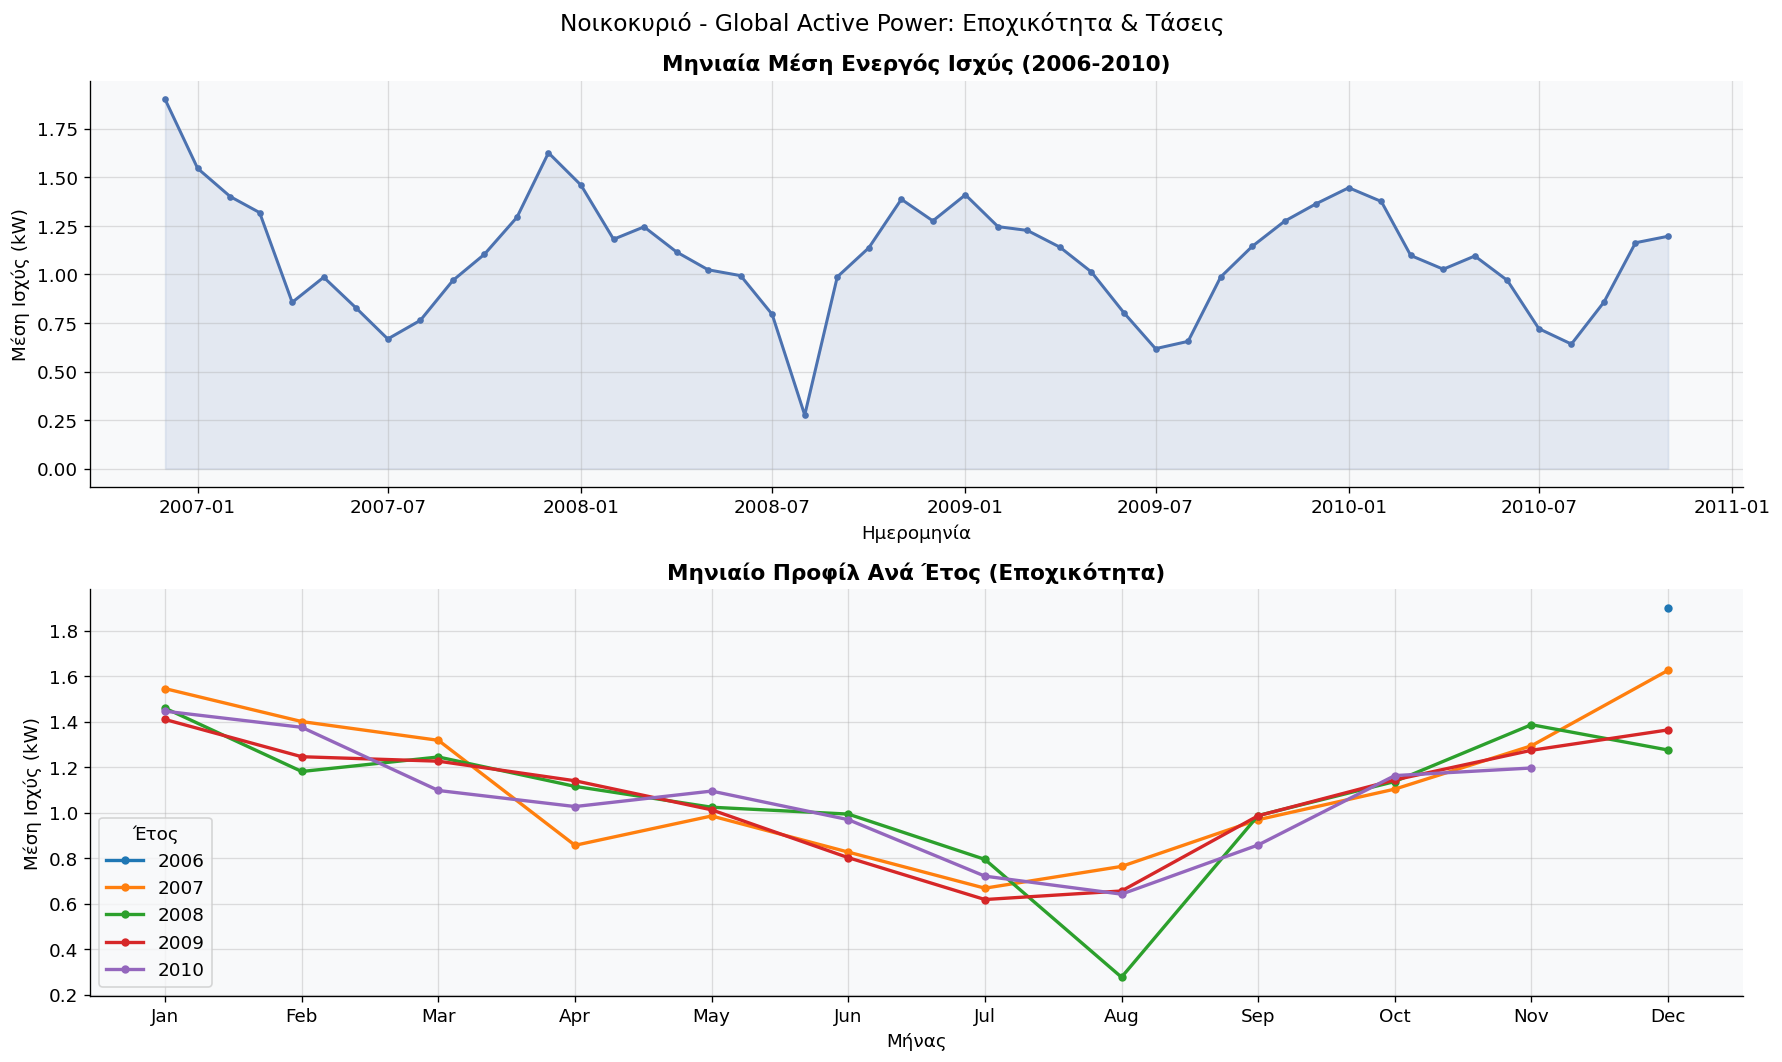

Έντονες χειμερινές αιχμές (Δεκ-Φεβ) λόγω ζήτησης θέρμανσης.
Καλοκαιρινή κατανάλωση σαφώς χαμηλότερη - χαρακτηριστικό γαλλικών νοικοκυριών (χωρίς κεντρικό κλιματισμό).
Τα προφίλ ανά έτος είναι ιδιαίτερα συνεπή, επιβεβαιώνοντας σταθερή εποχική δομή.


In [13]:
monthly_avg = hh_clean.groupby(['Year','Month'])['Global_active_power'].mean().reset_index()
monthly_avg['YearMonth'] = pd.to_datetime(monthly_avg[['Year','Month']].assign(day=1))

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle('Νοικοκυριό - Global Active Power: Εποχικότητα & Τάσεις', fontsize=14)

axes[0].plot(monthly_avg['YearMonth'], monthly_avg['Global_active_power'],
             color=PALETTE[0], linewidth=1.8, marker='o', markersize=3)
axes[0].fill_between(monthly_avg['YearMonth'], monthly_avg['Global_active_power'],
                     alpha=0.12, color=PALETTE[0])
axes[0].set_title('Μηνιαία Μέση Ενεργός Ισχύς (2006-2010)')
axes[0].set_xlabel('Ημερομηνία')
axes[0].set_ylabel('Μέση Ισχύς (kW)')

for yr, grp in monthly_avg.groupby('Year'):
    axes[1].plot(grp['Month'], grp['Global_active_power'],
                 label=str(yr), linewidth=2, marker='o', markersize=4)
axes[1].set_title('Μηνιαίο Προφίλ Ανά Έτος (Εποχικότητα)')
axes[1].set_xlabel('Μήνας')
axes[1].set_ylabel('Μέση Ισχύς (kW)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].legend(title='Έτος')

plt.tight_layout()
plt.savefig('fig7_hh_seasonality.png', bbox_inches='tight')
plt.show()

print('Έντονες χειμερινές αιχμές (Δεκ-Φεβ) λόγω ζήτησης θέρμανσης.')
print('Καλοκαιρινή κατανάλωση σαφώς χαμηλότερη - χαρακτηριστικό γαλλικών νοικοκυριών (χωρίς κεντρικό κλιματισμό).')
print('Τα προφίλ ανά έτος είναι ιδιαίτερα συνεπή, επιβεβαιώνοντας σταθερή εποχική δομή.')


---
# Μέρος 2: Κατανάλωση Ηλεκτρικής Ενέργειας Νοικοκυριού
## Dataset: household_power_consumption.txt

Το dataset περιέχει **2.075.259 μετρήσεις ανά λεπτό** ηλεκτρικής ισχύος ενός νοικοκυριού στο Sceaux της Γαλλίας (Δεκέμβριος 2006 - Νοέμβριος 2010). Μεταβλητές: ενεργός/αντιδραστική ισχύς, τάση, ένταση ρεύματος και τρία κανάλια υπό-μέτρησης (κουζίνα, πλυντήριο, θερμοσίφωνας/κλιματισμός).


Μέση ημερήσια κατανάλωση : 1.0872 kW  (26.09 kWh/ημέρα)
Μέση ωριαία κατανάλωση   : 1.0861 kW
Ώρα αιχμής ζήτησης        : 20:00  (1.8865 kW)
Ώρα κατώτατης ζήτησης     : 4:00  (0.4462 kW)


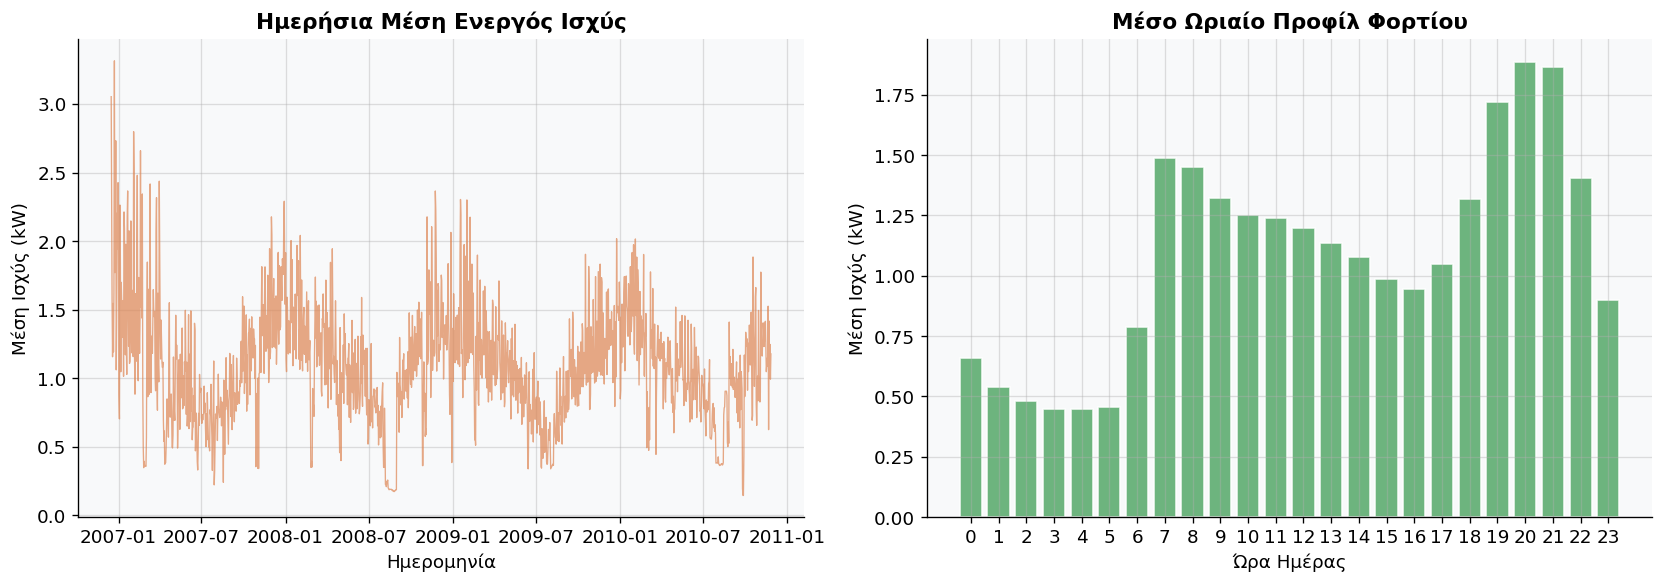

In [14]:
daily_avg  = hh_clean.resample('d')['Global_active_power'].mean()
hourly_avg = hh_clean.groupby('Hour')['Global_active_power'].mean()

print(f'Μέση ημερήσια κατανάλωση : {daily_avg.mean():.4f} kW  ({daily_avg.mean()*24:.2f} kWh/ημέρα)')
print(f'Μέση ωριαία κατανάλωση   : {hourly_avg.mean():.4f} kW')
print(f'Ώρα αιχμής ζήτησης        : {hourly_avg.idxmax()}:00  ({hourly_avg.max():.4f} kW)')
print(f'Ώρα κατώτατης ζήτησης     : {hourly_avg.idxmin()}:00  ({hourly_avg.min():.4f} kW)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(daily_avg.index, daily_avg.values, color=PALETTE[1], linewidth=0.8, alpha=0.7)
axes[0].set_title('Ημερήσια Μέση Ενεργός Ισχύς')
axes[0].set_xlabel('Ημερομηνία')
axes[0].set_ylabel('Μέση Ισχύς (kW)')

axes[1].bar(hourly_avg.index, hourly_avg.values, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1].set_title('Μέσο Ωριαίο Προφίλ Φορτίου')
axes[1].set_xlabel('Ώρα Ημέρας')
axes[1].set_ylabel('Μέση Ισχύς (kW)')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.savefig('fig8_daily_hourly.png', bbox_inches='tight')
plt.show()


### 2.1 Φόρτωση Δεδομένων & Προεπεξεργασία

Σχήμα ωριαία δείγματος: (34589, 7)


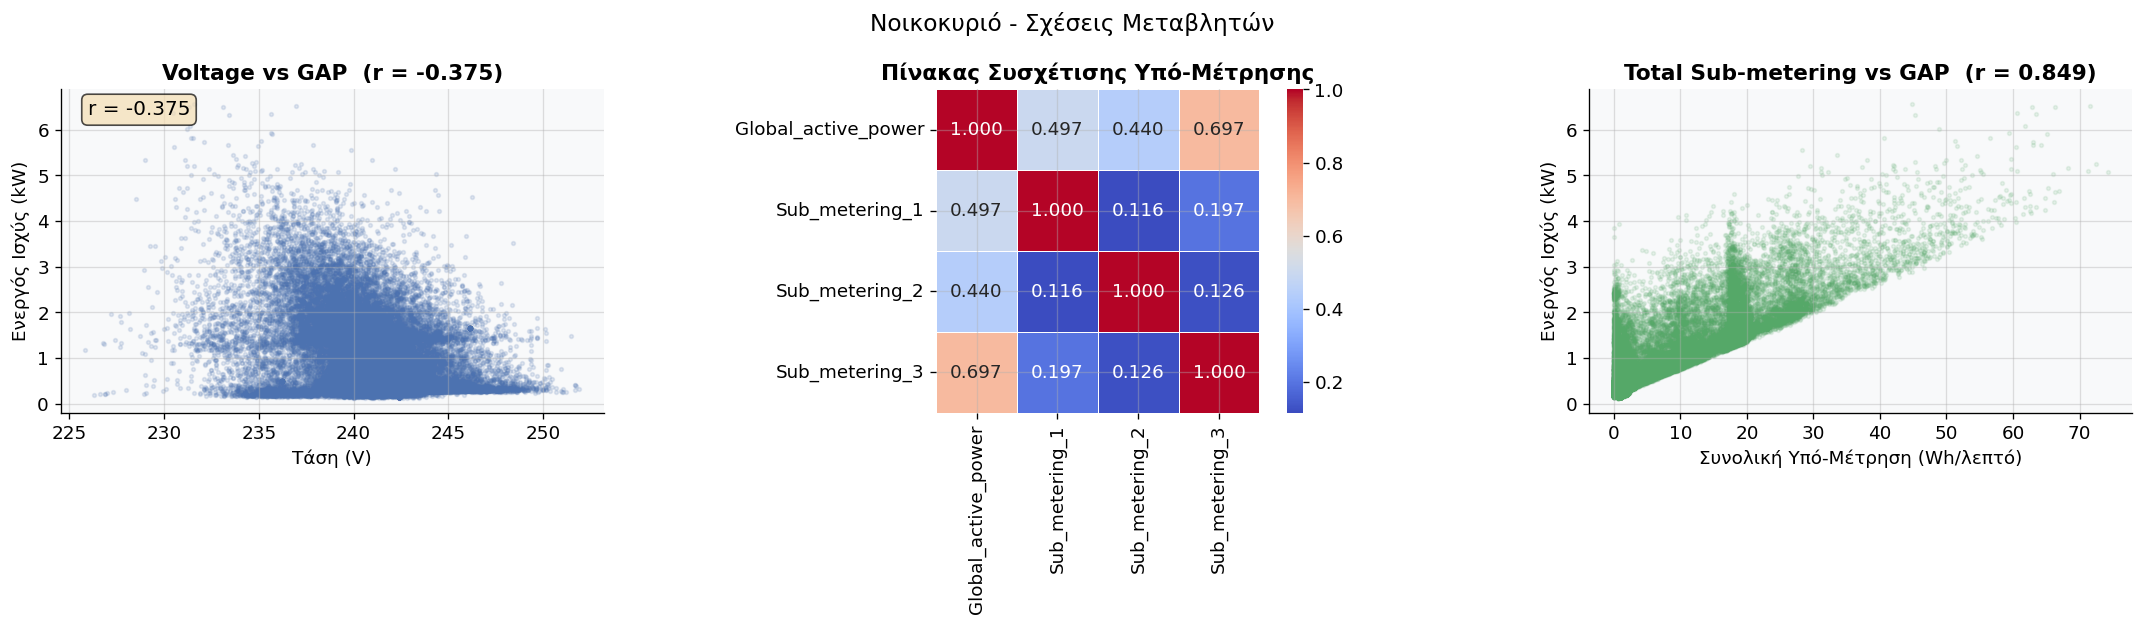

Συσχέτιση Τάσης vs GAP           : -0.3745
Αδύναμη αρνητική: υψηλότερη τάση μειώνει ελαφρά το ρεύμα (νόμος Ohm).
Συνολική υπό-μέτρηση vs GAP      : 0.8489
Μέτρια θετική: οι υπό-μετρητές καταγράφουν μέρος της συνολικής κατανάλωσης.


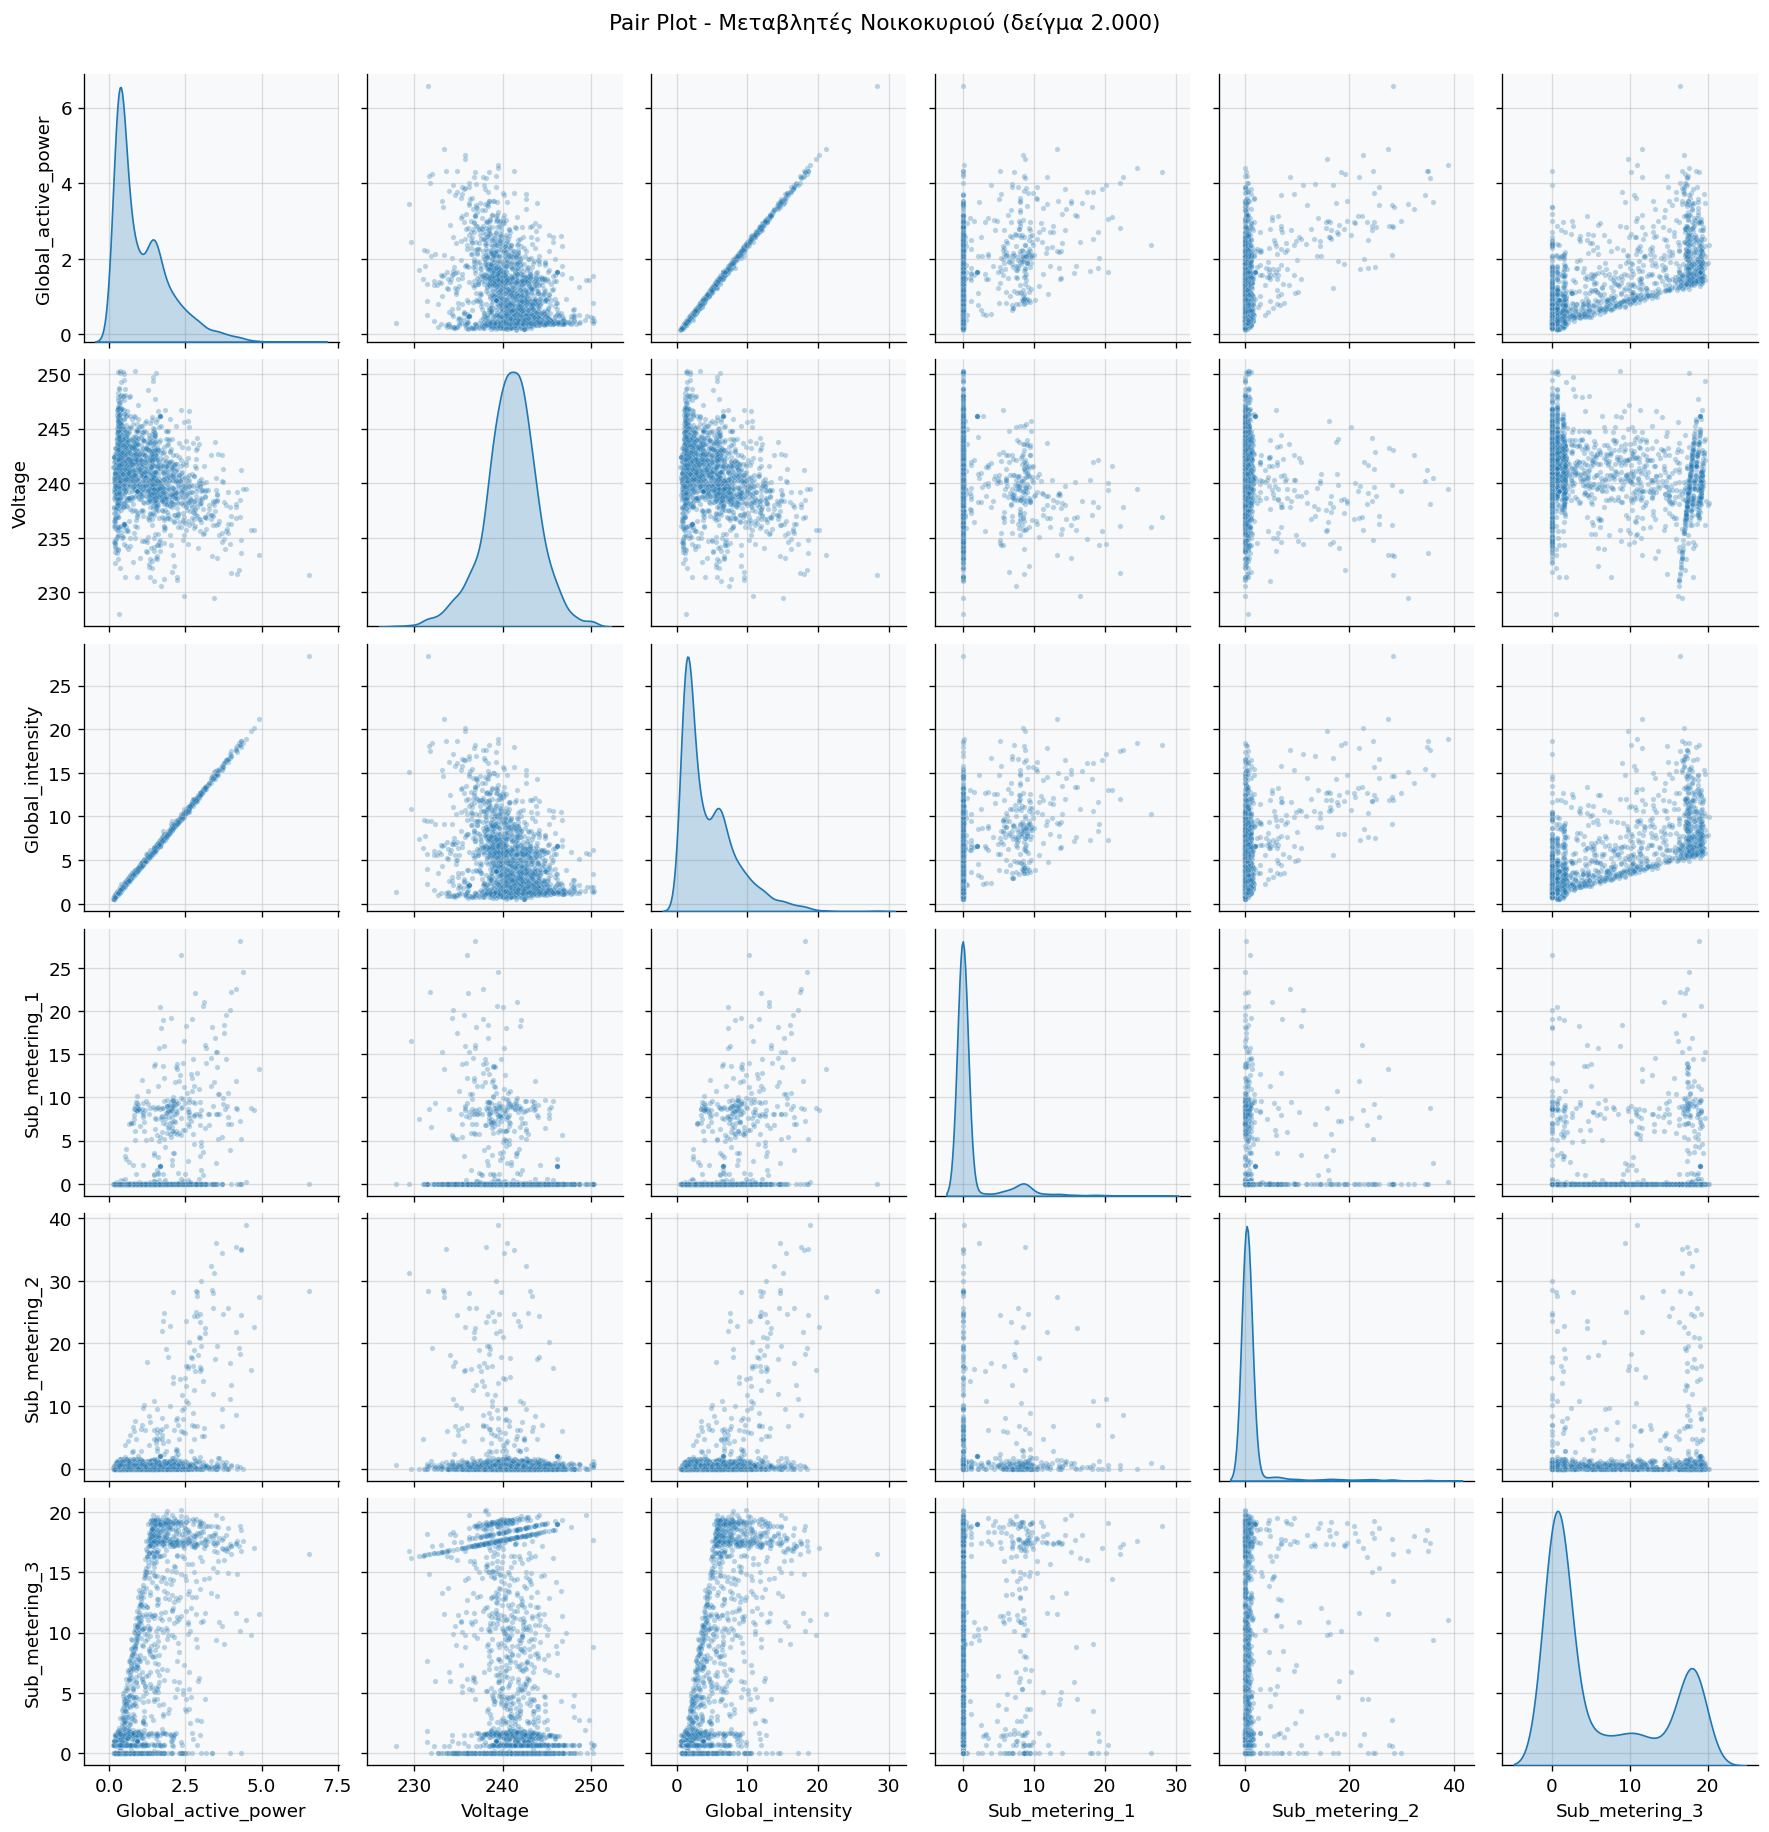

Variance Inflation Factor (VIF):
       Χαρακτηριστικό  VIF
     Global_intensity 9.18
              Voltage 5.54
Global_reactive_power 5.25
       Sub_metering_3 3.98
       Sub_metering_1 1.71
       Sub_metering_2 1.59
VIF > 10 υποδηλώνει υψηλή πολυσυγγραμμικότητα.
Αναμένεται υψηλό VIF για Global_intensity λόγω P = V x I.


In [15]:
hh_hourly = hh_clean[num_cols].resample('h').mean().dropna()
print(f'Σχήμα ωριαία δείγματος: {hh_hourly.shape}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Νοικοκυριό - Σχέσεις Μεταβλητών', fontsize=14)

axes[0].scatter(hh_hourly['Voltage'], hh_hourly['Global_active_power'],
                alpha=0.15, color=PALETTE[0], s=5)
r_volt = hh_hourly[['Voltage','Global_active_power']].corr().iloc[0,1]
axes[0].set_xlabel('Τάση (V)')
axes[0].set_ylabel('Ενεργός Ισχύς (kW)')
axes[0].set_title(f'Voltage vs GAP  (r = {r_volt:.3f})')
axes[0].text(0.05, 0.92, f'r = {r_volt:.3f}', transform=axes[0].transAxes,
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

sub_corr = hh_hourly[['Global_active_power','Sub_metering_1','Sub_metering_2','Sub_metering_3']].corr()
sns.heatmap(sub_corr, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[1],
            cbar=True, square=True, linewidths=0.5)
axes[1].set_title('Πίνακας Συσχέτισης Υπό-Μέτρησης')

total_sub = hh_hourly['Sub_metering_1'] + hh_hourly['Sub_metering_2'] + hh_hourly['Sub_metering_3']
axes[2].scatter(total_sub, hh_hourly['Global_active_power'], alpha=0.12, color=PALETTE[2], s=5)
r_sub = total_sub.corr(hh_hourly['Global_active_power'])
axes[2].set_xlabel('Συνολική Υπό-Μέτρηση (Wh/λεπτό)')
axes[2].set_ylabel('Ενεργός Ισχύς (kW)')
axes[2].set_title(f'Total Sub-metering vs GAP  (r = {r_sub:.3f})')

plt.tight_layout()
plt.savefig('fig9_correlations.png', bbox_inches='tight')
plt.show()

print(f'Συσχέτιση Τάσης vs GAP           : {r_volt:.4f}')
print('Αδύναμη αρνητική: υψηλότερη τάση μειώνει ελαφρά το ρεύμα (νόμος Ohm).')
print(f'Συνολική υπό-μέτρηση vs GAP      : {r_sub:.4f}')
print('Μέτρια θετική: οι υπό-μετρητές καταγράφουν μέρος της συνολικής κατανάλωσης.')

pair_cols = ['Global_active_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']
sample_pair = hh_hourly[pair_cols].sample(2000, random_state=SEED)
pair_fig = sns.pairplot(sample_pair, diag_kind='kde', plot_kws={'alpha':0.3, 's':10})
pair_fig.fig.suptitle('Pair Plot - Μεταβλητές Νοικοκυριού (δείγμα 2.000)', y=1.02, fontsize=13)
plt.savefig('fig9b_pairplot.png', bbox_inches='tight')
plt.show()

# VIF — Έλεγχος Πολυσυγγραμμικότητας
vif_features = ['Global_reactive_power','Voltage','Global_intensity',
                'Sub_metering_1','Sub_metering_2','Sub_metering_3']
vif_data = hh_hourly[vif_features].dropna()
vif_df = pd.DataFrame({
    'Χαρακτηριστικό': vif_features,
    'VIF': [variance_inflation_factor(vif_data.values, j)
            for j in range(len(vif_features))]
}).round(2)
print('Variance Inflation Factor (VIF):')
print(vif_df.sort_values('VIF', ascending=False).to_string(index=False))
print('VIF > 10 υποδηλώνει υψηλή πολυσυγγραμμικότητα.')
print('Αναμένεται υψηλό VIF για Global_intensity λόγω P = V x I.')


### 2.2 Στατιστική Ανάλυση
#### 2.2.1 Ανάλυση Χρονοσειράς: Εποχικότητα & Τάσεις

Πλήρες Μοντέλο (6 χαρακτηριστικά):
  R2   : 0.9995
  RMSE : 0.0207 kW
  MAE  : 0.0144 kW

       Χαρακτηριστικό  Συντελεστής
     Global_intensity     0.240348
Global_reactive_power    -0.189855
              Voltage     0.004585
       Sub_metering_3     0.001597
       Sub_metering_1    -0.001444
       Sub_metering_2    -0.001053


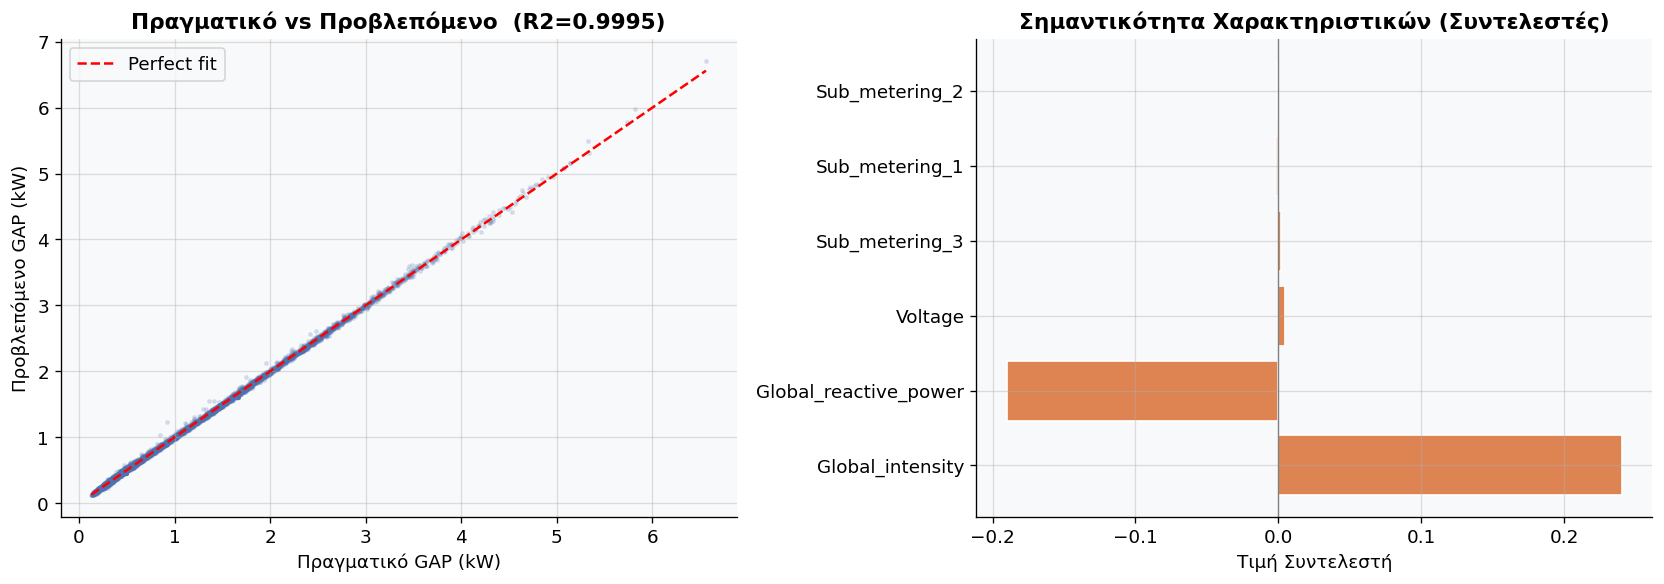

TimeSeriesSplit R2 (5-fold): 0.9994 ± 0.0002
Χρονικός διαχωρισμός αποφεύγει data leakage μεταξύ παρελθόντος και μέλλοντος.
          Μοντέλο     R2
Linear Regression 0.9995
    Ridge (α=1.0) 0.9995
  Lasso (α=0.001) 0.9995
Ridge/Lasso με κανονικοποίηση συγκρίνεται με plain Linear Regression.


In [16]:
features_all = ['Global_reactive_power','Voltage','Global_intensity',
                'Sub_metering_1','Sub_metering_2','Sub_metering_3']
target = 'Global_active_power'

X = hh_hourly[features_all]
y = hh_hourly[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

lr_full = LinearRegression()
lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_test)

r2   = r2_score(y_test, y_pred_full)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_full))
mae  = mean_absolute_error(y_test, y_pred_full)

print('Πλήρες Μοντέλο (6 χαρακτηριστικά):')
print(f'  R2   : {r2:.4f}')
print(f'  RMSE : {rmse:.4f} kW')
print(f'  MAE  : {mae:.4f} kW')
print()
coef_df = pd.DataFrame({'Χαρακτηριστικό': features_all, 'Συντελεστής': lr_full.coef_})
coef_df = coef_df.sort_values('Συντελεστής', key=abs, ascending=False)
print(coef_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_full, alpha=0.15, s=4, color=PALETTE[0])
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Πραγματικό GAP (kW)')
axes[0].set_ylabel('Προβλεπόμενο GAP (kW)')
axes[0].set_title(f'Πραγματικό vs Προβλεπόμενο  (R2={r2:.4f})')
axes[0].legend()

axes[1].barh(coef_df['Χαρακτηριστικό'], coef_df['Συντελεστής'], color=PALETTE[1], edgecolor='white')
axes[1].set_xlabel('Τιμή Συντελεστή')
axes[1].set_title('Σημαντικότητα Χαρακτηριστικών (Συντελεστές)')
axes[1].axvline(0, color='grey', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig10_regression_full.png', bbox_inches='tight')
plt.show()

# TimeSeriesSplit — Χρονικά Σωστός Διαχωρισμός
tscv = TimeSeriesSplit(n_splits=5)
ts_scores = []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    lr_ts = LinearRegression().fit(X_tr, y_tr)
    ts_scores.append(r2_score(y_te, lr_ts.predict(X_te)))
print(f'TimeSeriesSplit R2 (5-fold): {np.mean(ts_scores):.4f} ± {np.std(ts_scores):.4f}')
print('Χρονικός διαχωρισμός αποφεύγει data leakage μεταξύ παρελθόντος και μέλλοντος.')

# Ridge και Lasso για σύγκριση
from sklearn.preprocessing import StandardScaler as SS
scaler_reg = SS()
X_train_s = scaler_reg.fit_transform(X_train)
X_test_s  = scaler_reg.transform(X_test)

ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)
lasso = Lasso(alpha=0.001).fit(X_train_s, y_train)

r2_ridge = r2_score(y_test, ridge.predict(X_test_s))
r2_lasso = r2_score(y_test, lasso.predict(X_test_s))

reg_comparison = pd.DataFrame({
    'Μοντέλο': ['Linear Regression', 'Ridge (α=1.0)', 'Lasso (α=0.001)'],
    'R2': [round(r2,4), round(r2_ridge,4), round(r2_lasso,4)]
})
print(reg_comparison.to_string(index=False))
print('Ridge/Lasso με κανονικοποίηση συγκρίνεται με plain Linear Regression.')


#### 2.5.1 Διαγνωστικά Υπολοίπων (Residual Diagnostics)

Για ένα μοντέλο με R²=0,9995, ο έλεγχος των υπολοίπων είναι απαραίτητος για να επιβεβαιωθεί ότι οι παραδοχές της γραμμικής παλινδρόμησης τηρούνται: κανονικότητα, ομοσκεδαστικότητα και απουσία συστηματικών μοτίβων.

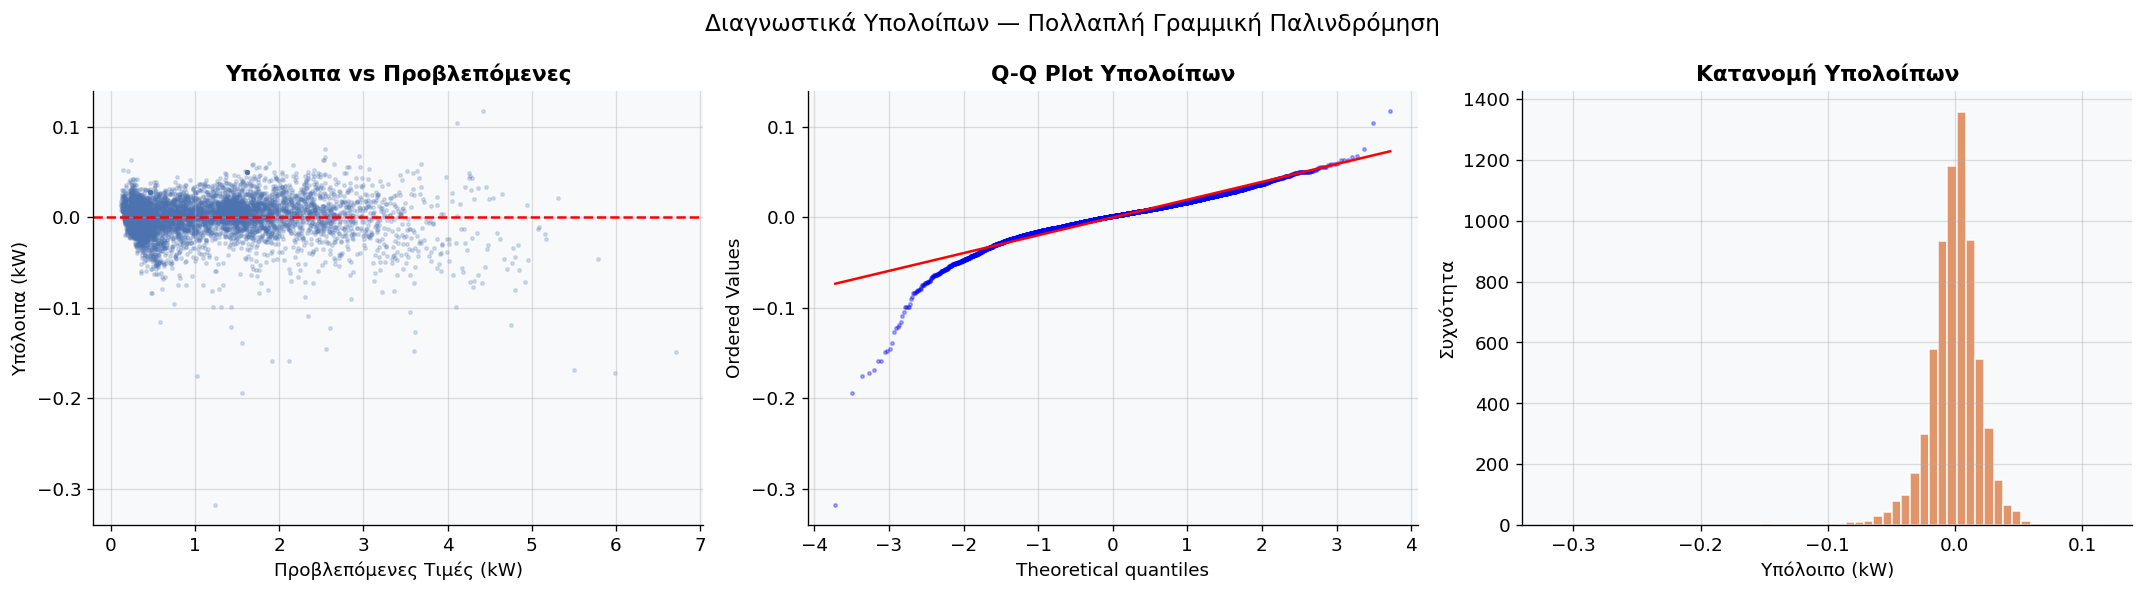

Μέσος υπολοίπων  : -0.000261 kW (αναμένεται ~0)
Τυπ. απόκλιση    : 0.0207 kW
Ελάχιστο         : -0.3186 kW
Μέγιστο          : 0.1179 kW

Ερμηνεία:
  Residuals vs Fitted: Αν τα υπόλοιπα είναι τυχαία κατανεμημένα γύρω από το 0,
    η γραμμική παραδοχή ισχύει. Συστηματικά μοτίβα υποδηλώνουν μη-γραμμικότητα.
  Q-Q Plot: Αν τα σημεία ακολουθούν τη διαγώνιο, τα υπόλοιπα είναι κανονικά.
    Αποκλίσεις στις ουρές υποδηλώνουν heavy-tailed κατανομή υπολοίπων.
  Histogram: Επιβεβαιώνει οπτικά την κατανομή των υπολοίπων.


In [17]:
# Υπολογισμός υπολοίπων
residuals = y_test - y_pred_full

fig_res, axes_res = plt.subplots(1, 3, figsize=(18, 5))
fig_res.suptitle('Διαγνωστικά Υπολοίπων — Πολλαπλή Γραμμική Παλινδρόμηση', fontsize=14)

# 1. Residuals vs Fitted
axes_res[0].scatter(y_pred_full, residuals, alpha=0.2, s=4, color=PALETTE[0])
axes_res[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes_res[0].set_xlabel('Προβλεπόμενες Τιμές (kW)')
axes_res[0].set_ylabel('Υπόλοιπα (kW)')
axes_res[0].set_title('Υπόλοιπα vs Προβλεπόμενες')

# 2. Q-Q Plot
probplot(residuals, dist='norm', plot=axes_res[1])
axes_res[1].set_title('Q-Q Plot Υπολοίπων')
axes_res[1].get_lines()[0].set(markersize=2, alpha=0.3)

# 3. Histogram υπολοίπων
axes_res[2].hist(residuals, bins=60, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes_res[2].set_xlabel('Υπόλοιπο (kW)')
axes_res[2].set_ylabel('Συχνότητα')
axes_res[2].set_title('Κατανομή Υπολοίπων')

plt.tight_layout()
plt.savefig('fig_residuals.png', bbox_inches='tight')
plt.show()

print(f'Μέσος υπολοίπων  : {residuals.mean():.6f} kW (αναμένεται ~0)')
print(f'Τυπ. απόκλιση    : {residuals.std():.4f} kW')
print(f'Ελάχιστο         : {residuals.min():.4f} kW')
print(f'Μέγιστο          : {residuals.max():.4f} kW')
print()
print('Ερμηνεία:')
print('  Residuals vs Fitted: Αν τα υπόλοιπα είναι τυχαία κατανεμημένα γύρω από το 0,')
print('    η γραμμική παραδοχή ισχύει. Συστηματικά μοτίβα υποδηλώνουν μη-γραμμικότητα.')
print('  Q-Q Plot: Αν τα σημεία ακολουθούν τη διαγώνιο, τα υπόλοιπα είναι κανονικά.')
print('    Αποκλίσεις στις ουρές υποδηλώνουν heavy-tailed κατανομή υπολοίπων.')
print('  Histogram: Επιβεβαιώνει οπτικά την κατανομή των υπολοίπων.')


#### 2.5.2 Grid Search για Ridge & Lasso — Βέλτιστο Alpha

Ο εντοπισμός του βέλτιστου hyperparameter α μέσω Grid Search εξασφαλίζει αντικειμενική σύγκριση μεταξύ των μοντέλων κανονικοποίησης.

In [18]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV — εσωτερικό cross-validation για βέλτιστο alpha
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_s, y_train)
r2_ridge_cv = r2_score(y_test, ridge_cv.predict(X_test_s))

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=5000)
lasso_cv.fit(X_train_s, y_train)
r2_lasso_cv = r2_score(y_test, lasso_cv.predict(X_test_s))

grid_results = pd.DataFrame({
    'Μοντέλο': ['Ridge (βέλτιστο α)', 'Lasso (βέλτιστο α)'],
    'Βέλτιστο Alpha': [round(ridge_cv.alpha_, 4), round(lasso_cv.alpha_, 4)],
    'R2': [round(r2_ridge_cv, 4), round(r2_lasso_cv, 4)]
})
print('Grid Search — Βέλτιστο Alpha:')
print(grid_results.to_string(index=False))
print()
print('Ridge: Συρρικνώνει όλους τους συντελεστές αλλά δεν τους μηδενίζει.')
print('       Κατάλληλο όταν υπάρχει πολυσυγγραμμικότητα (π.χ. Global_intensity).')
print('Lasso: Μπορεί να μηδενίσει συντελεστές (feature selection).')
print('       Χρήσιμο για αναγνώριση των πραγματικά σημαντικών μεταβλητών.')

# Lasso coefficients — ποιες μεταβλητές επιβιώνουν
lasso_coef = pd.DataFrame({
    'Χαρακτηριστικό': features_all,
    'Lasso Συντελεστής': lasso_cv.coef_.round(4)
}).sort_values('Lasso Συντελεστής', key=abs, ascending=False)
print()
print('Lasso Συντελεστές (μηδενικοί = αφαιρέθηκαν):')
print(lasso_coef.to_string(index=False))


Grid Search — Βέλτιστο Alpha:
           Μοντέλο  Βέλτιστο Alpha     R2
Ridge (βέλτιστο α)           0.001 0.9995
Lasso (βέλτιστο α)           0.001 0.9995

Ridge: Συρρικνώνει όλους τους συντελεστές αλλά δεν τους μηδενίζει.
       Κατάλληλο όταν υπάρχει πολυσυγγραμμικότητα (π.χ. Global_intensity).
Lasso: Μπορεί να μηδενίσει συντελεστές (feature selection).
       Χρήσιμο για αναγνώριση των πραγματικά σημαντικών μεταβλητών.

Lasso Συντελεστές (μηδενικοί = αφαιρέθηκαν):
       Χαρακτηριστικό  Lasso Συντελεστής
     Global_intensity             0.8948
       Sub_metering_3             0.0127
              Voltage             0.0122
Global_reactive_power            -0.0119
       Sub_metering_1            -0.0027
       Sub_metering_2            -0.0022


In [19]:
features_reduced = ['Global_reactive_power','Voltage','Sub_metering_1','Sub_metering_2','Sub_metering_3']

X_r = hh_hourly[features_reduced]
X_r_train, X_r_test, _, _ = train_test_split(X_r, y, test_size=0.2, random_state=SEED)

lr_red = LinearRegression()
lr_red.fit(X_r_train, y_train)
y_pred_red = lr_red.predict(X_r_test)

r2_r   = r2_score(y_test, y_pred_red)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_red))
mae_r  = mean_absolute_error(y_test, y_pred_red)

comparison = pd.DataFrame({
    'Μοντέλο': ['Πλήρες (6 χαρ.)', 'Μειωμένο (5 χαρ., -Global_intensity)'],
    'R2':    [round(r2,4), round(r2_r,4)],
    'RMSE':  [round(rmse,4), round(rmse_r,4)],
    'MAE':   [round(mae,4), round(mae_r,4)]
})
print(comparison.to_string(index=False))
print()
print('Η Global_intensity είναι σχεδόν ντετερμινιστική συνάρτηση του GAP (P = V × I).')
print('Η αφαίρεσή της προκαλεί απότομη πτώση R2, επιβεβαιώνοντάς την ως κυρίαρχο προβλεπτή.')
print('Τα υπόλοιπα χαρακτηριστικά εξηγούν μέρος της υπολειπόμενης διακύμανσης.')
print('Σε πραγματικό σενάριο πρόβλεψης, χρήση χρονικά καθυστερημένης τιμής ισχύος αποφεύγει data leakage.')


                             Μοντέλο     R2   RMSE    MAE
                     Πλήρες (6 χαρ.) 0.9995 0.0207 0.0144
Μειωμένο (5 χαρ., -Global_intensity) 0.7450 0.4537 0.3233

Η Global_intensity είναι σχεδόν ντετερμινιστική συνάρτηση του GAP (P = V × I).
Η αφαίρεσή της προκαλεί απότομη πτώση R2, επιβεβαιώνοντάς την ως κυρίαρχο προβλεπτή.
Τα υπόλοιπα χαρακτηριστικά εξηγούν μέρος της υπολειπόμενης διακύμανσης.
Σε πραγματικό σενάριο πρόβλεψης, χρήση χρονικά καθυστερημένης τιμής ισχύος αποφεύγει data leakage.


#### 2.2.2 Μέση Ημερήσια & Ωριαία Κατανάλωση

Είσοδος clustering: 34,589 ωριαίες παρατηρήσεις x 7 χαρακτηριστικά
Βέλτιστο k (αγκώνας): 5


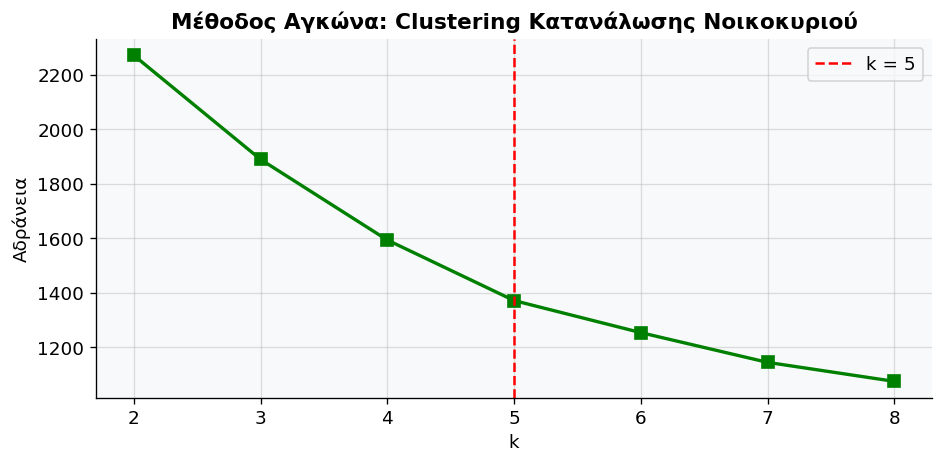

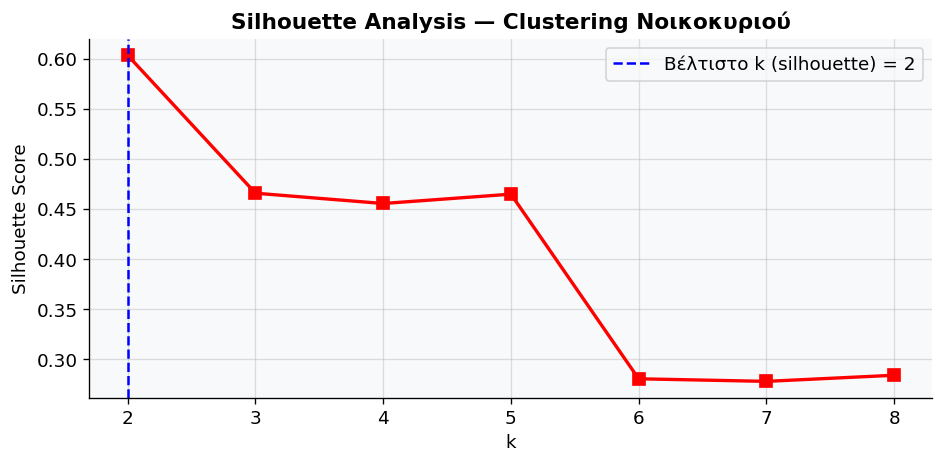

Silhouette scores ανά k (νοικοκυριό):
  k=2: 0.6031
  k=3: 0.4657
  k=4: 0.4555
  k=5: 0.4648
  k=6: 0.2807
  k=7: 0.2781
  k=8: 0.2842
Βέλτιστο k βάσει Silhouette: 2
Βέλτιστο k βάσει Elbow     : 5


In [20]:
cluster_features = ['Global_active_power','Global_reactive_power',
                     'Voltage','Global_intensity',
                     'Sub_metering_1','Sub_metering_2','Sub_metering_3']

hh_clust = hh_hourly[cluster_features].dropna().copy()
print(f'Είσοδος clustering: {len(hh_clust):,} ωριαίες παρατηρήσεις x {len(cluster_features)} χαρακτηριστικά')

mm_scaler = MinMaxScaler()
X_clust   = mm_scaler.fit_transform(hh_clust)

inertias2   = []
silhouettes2 = []
k_range2  = range(2, 9)
for k in k_range2:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels2 = km.fit_predict(X_clust)
    inertias2.append(km.inertia_)
    silhouettes2.append(silhouette_score(X_clust, labels2, sample_size=3000, random_state=SEED))

kl2 = KneeLocator(list(k_range2), inertias2, curve='convex', direction='decreasing')
opt_k2 = kl2.knee or 4
print(f'Βέλτιστο k (αγκώνας): {opt_k2}')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(list(k_range2), inertias2, 'gs-', linewidth=2, markersize=7)
ax.axvline(opt_k2, color='red', linestyle='--', label=f'k = {opt_k2}')
ax.set_xlabel('k')
ax.set_ylabel('Αδράνεια')
ax.set_title('Μέθοδος Αγκώνα: Clustering Κατανάλωσης Νοικοκυριού')
ax.legend()
plt.tight_layout()
plt.savefig('fig11_elbow_part2.png', bbox_inches='tight')
plt.show()

# Silhouette Analysis — Νοικοκυριό
fig_sil2, ax_sil2 = plt.subplots(figsize=(8, 4))
ax_sil2.plot(list(k_range2), silhouettes2, 'rs-', linewidth=2, markersize=7)
best_k2_sil = list(k_range2)[silhouettes2.index(max(silhouettes2))]
ax_sil2.axvline(best_k2_sil, color='blue', linestyle='--',
                label=f'Βέλτιστο k (silhouette) = {best_k2_sil}')
ax_sil2.set_xlabel('k')
ax_sil2.set_ylabel('Silhouette Score')
ax_sil2.set_title('Silhouette Analysis — Clustering Νοικοκυριού')
ax_sil2.legend()
plt.tight_layout()
plt.savefig('fig_silhouette_hh.png', bbox_inches='tight')
plt.show()
print('Silhouette scores ανά k (νοικοκυριό):')
for k, s in zip(k_range2, silhouettes2):
    print(f'  k={k}: {s:.4f}')
print(f'Βέλτιστο k βάσει Silhouette: {best_k2_sil}')
print(f'Βέλτιστο k βάσει Elbow     : {opt_k2}')


Προφίλ Ομάδων (μέσες τιμές):
         Global_active_power  Global_reactive_power  Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3
Cluster                                                                                                                       
0                      1.211                  0.121  240.741             5.102           0.682           0.630           9.374
1                      1.852                  0.171  239.253             7.868           3.644           4.434           1.715
2                      3.330                  0.207  237.750            14.115           7.429           8.966          16.013
3                      0.437                  0.111  241.795             1.909           0.155           0.404           0.917
4                      1.770                  0.115  239.910             7.374           1.149           0.688          17.796


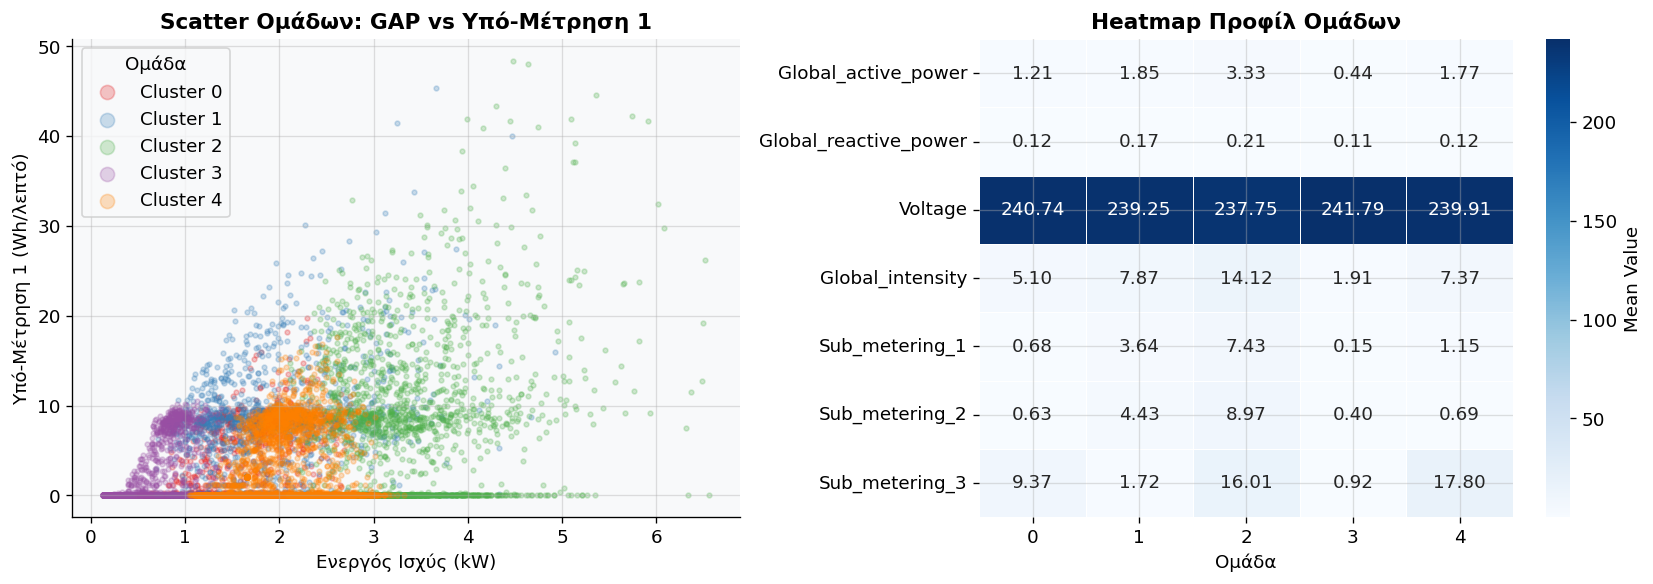

Ερμηνεία Ομάδων:
  Cluster 0: Mean GAP = 1.211 kW -> Χαμηλή κατανάλωση (νυχτερινό / εκτός αιχμής)
  Cluster 1: Mean GAP = 1.852 kW -> Υψηλή κατανάλωση (απογευματινή αιχμή / βαριές συσκευές)
  Cluster 2: Mean GAP = 3.330 kW -> Υψηλή κατανάλωση (απογευματινή αιχμή / βαριές συσκευές)
  Cluster 3: Mean GAP = 0.437 kW -> Χαμηλή κατανάλωση (νυχτερινό / εκτός αιχμής)
  Cluster 4: Mean GAP = 1.770 kW -> Μέτρια κατανάλωση (ημερήσιο βασικό φορτίο)


In [21]:
km2 = KMeans(n_clusters=opt_k2, random_state=SEED, n_init=20)
hh_clust['Cluster'] = km2.fit_predict(X_clust)

cluster_profile = hh_clust.groupby('Cluster')[cluster_features].mean().round(3)
print('Προφίλ Ομάδων (μέσες τιμές):')
print(cluster_profile.to_string())

colours_c2 = sns.color_palette('Set1', opt_k2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(opt_k2):
    mask = hh_clust['Cluster'] == c
    axes[0].scatter(hh_clust.loc[mask,'Global_active_power'],
                    hh_clust.loc[mask,'Sub_metering_1'],
                    s=8, alpha=0.25, color=colours_c2[c], label=f'Cluster {c}')
axes[0].set_xlabel('Ενεργός Ισχύς (kW)')
axes[0].set_ylabel('Υπό-Μέτρηση 1 (Wh/λεπτό)')
axes[0].set_title('Scatter Ομάδων: GAP vs Υπό-Μέτρηση 1')
axes[0].legend(markerscale=3, title='Ομάδα')

sns.heatmap(cluster_profile.T, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Mean Value'})
axes[1].set_title('Heatmap Προφίλ Ομάδων')
axes[1].set_xlabel('Ομάδα')

plt.tight_layout()
plt.savefig('fig12_cluster_hh.png', bbox_inches='tight')
plt.show()

print('Ερμηνεία Ομάδων:')
for c in range(opt_k2):
    avg_gap = cluster_profile.loc[c,'Global_active_power']
    q33 = cluster_profile['Global_active_power'].quantile(0.33)
    q67 = cluster_profile['Global_active_power'].quantile(0.67)
    if avg_gap < q33:
        label = 'Χαμηλή κατανάλωση (νυχτερινό / εκτός αιχμής)'
    elif avg_gap < q67:
        label = 'Μέτρια κατανάλωση (ημερήσιο βασικό φορτίο)'
    else:
        label = 'Υψηλή κατανάλωση (απογευματινή αιχμή / βαριές συσκευές)'
    print(f'  Cluster {c}: Mean GAP = {avg_gap:.3f} kW -> {label}')


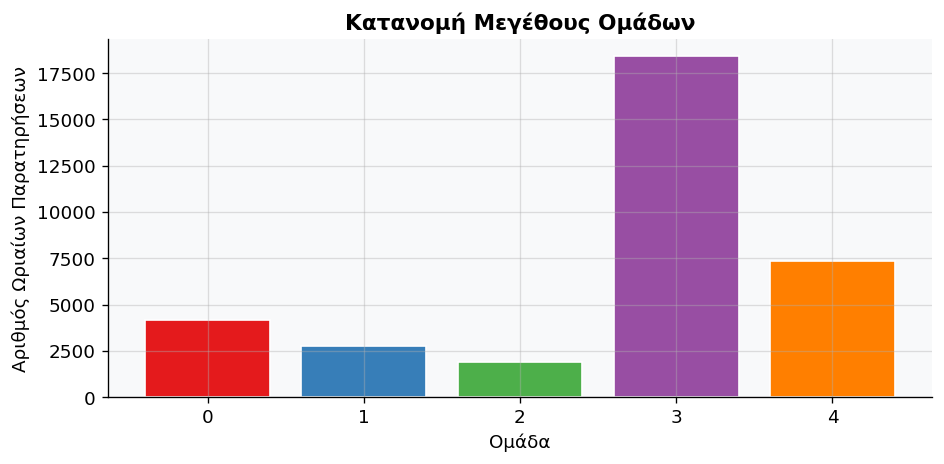

Τα μοτίβα κατανάλωσης ανά ομάδα επιβεβαιώνουν τη δομή καθεστώτων.
Η ομάδα υψηλής ζήτησης αντιστοιχεί κυρίως σε χειμερινά απογεύματα καθημερινών.
Η ομάδα χαμηλής ζήτησης ευθυγραμμίζεται με νυχτερινές και καλοκαιρινές περιόδους.


In [22]:
cluster_counts = hh_clust['Cluster'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cluster_counts.index, cluster_counts.values,
       color=[colours_c2[c] for c in cluster_counts.index], edgecolor='white')
ax.set_xlabel('Ομάδα')
ax.set_ylabel('Αριθμός Ωριαίων Παρατηρήσεων')
ax.set_title('Κατανομή Μεγέθους Ομάδων')
ax.set_xticks(range(opt_k2))
plt.tight_layout()
plt.savefig('fig13_cluster_sizes.png', bbox_inches='tight')
plt.show()

print('Τα μοτίβα κατανάλωσης ανά ομάδα επιβεβαιώνουν τη δομή καθεστώτων.')
print('Η ομάδα υψηλής ζήτησης αντιστοιχεί κυρίως σε χειμερινά απογεύματα καθημερινών.')
print('Η ομάδα χαμηλής ζήτησης ευθυγραμμίζεται με νυχτερινές και καλοκαιρινές περιόδους.')


#### 2.2.3 Συσχετίσεις Μεταβλητών: Scatter Plots, Pair Plots, Heatmap

---
## Βιβλιογραφία

[1] Matthes, E. (2015). *Python Crash Course: A Hands-On, Project-Based Introduction to Programming*. No Starch Press.

[2] Barry, P. (2016). *Head First Python, 2nd Edition: A Brain-Friendly Guide*. O'Reilly Media.

[3] Shaw, Z. (2013). *Learn Python the Hard Way*. Addison-Wesley.

[4] Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, 3rd ed. O'Reilly Media.

[5] Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html

[6] UCI Machine Learning Repository. (2012). *Individual Household Electric Power Consumption Dataset*. https://archive.ics.uci.edu/ml/datasets/individual+household+electric+power+consumption

[7] Kaggle. (2018). *PJM Hourly Energy Consumption*. https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

[8] Hunter, J.D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.

[9] Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021. https://doi.org/10.21105/joss.03021

[10] Seabold, S. & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*.
